In [5]:
import soundfile as sf, librosa, traceback

CLIP = "/home/jgersey/SageBat/detected_clips/20260414_100939_det0004.wav"

print(sf.info(CLIP))          # format, subtype, samplerate, frames

for name, fn in [
    ("soundfile", lambda: sf.read(CLIP)),
    ("librosa native", lambda: librosa.load(CLIP, sr=None)),
    ("librosa @256k", lambda: librosa.load(CLIP, sr=256000)),
]:
    try:
        y, sr = fn()
        print(f"{name}: OK  {len(y)} samples @ {sr}")
    except Exception:
        print(f"{name}: FAILED")
        traceback.print_exc()

/home/jgersey/SageBat/detected_clips/20260414_100939_det0004.wav
samplerate: 384000 Hz
channels: 1
duration: 384000 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]
soundfile: OK  384000 samples @ 384000


/home/jgersey/SageBat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


librosa native: OK  384000 samples @ 384000
librosa @256k: OK  256000 samples @ 256000


In [ ]:
# =========================================================
# Run BattyBirdNET on the full 10-minute recording
# =========================================================
import os, glob, subprocess, tempfile, time
import numpy as np, soundfile as sf, pandas as pd
from scipy.signal import resample_poly, butter, sosfiltfilt

BBN_DIR  = "/home/jgersey/SageBat/BattyBirdNET-Analyzer"
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"

HIGHPASS = 20_000     # Hz; None to disable. Suppresses the insect chorus.
AREA     = "USA"
MIN_CONF = 0.1
OVERLAP  = 0.0        # keep 0 for a long file — runtime scales with this

info = sf.info(FULL_WAV)
SR = info.samplerate
assert SR == 384000, f"expected 384 kHz, got {SR}"
print(f"{info.duration:.1f} s, {info.frames} samples")

work = tempfile.mkdtemp(prefix="bbn_full_")
out  = os.path.join(work, "results"); os.makedirs(out, exist_ok=True)
dest = os.path.join(work, os.path.basename(FULL_WAV))

# --- pass 1: peak, for int16 scaling ---
peak = 0.0
with sf.SoundFile(FULL_WAV) as f:
    while True:
        b = f.read(frames=3_000_000, dtype="float32", always_2d=True)
        if not len(b):
            break
        peak = max(peak, float(np.abs(b[:, 0]).max()))
print(f"peak amplitude {peak:.4f}")
scale = 0.98 / (peak + 1e-12)

# --- pass 2: highpass + resample 384k->256k, stream to disk ---
BLK = 3_000_000          # multiple of 3 (the decimation factor)
PAD = 3 * 8192           # discarded each side to avoid filter edge effects
sos = butter(6, HIGHPASS, btype="highpass", fs=SR, output="sos") if HIGHPASS else None

t0 = time.time()
with sf.SoundFile(FULL_WAV) as fin, \
     sf.SoundFile(dest, "w", samplerate=256000, channels=1, subtype="PCM_16") as fout:
    pos = 0
    while pos < info.frames:
        start = max(0, pos - PAD)
        fin.seek(start)
        n = min(BLK + PAD + (pos - start), info.frames - start)
        y = fin.read(frames=n, dtype="float64", always_2d=True)[:, 0]
        if len(y) < 64:
            break
        if sos is not None:
            y = sosfiltfilt(sos, y)
        r = resample_poly(y, up=2, down=3)

        lead = (pos - start) * 2 // 3          # samples to drop at the front
        tail_pad = PAD * 2 // 3 if (start + n) < info.frames else 0
        r = r[lead:len(r) - tail_pad] if tail_pad else r[lead:]

        fout.write(np.clip(r * scale, -1, 1).astype(np.float32))
        pos += BLK
        print(f"  {pos/SR:6.0f}s / {info.duration:.0f}s", end="\r")

print(f"\nresampled in {time.time()-t0:.0f}s")
print(sf.info(dest))

# --- analyze ---
cmd = ["python3", "bat_ident.py", "--i", work, "--o", out,
       "--area", AREA, "--min_conf", str(MIN_CONF),
       "--overlap", str(OVERLAP), "--rtype", "csv"]
print(" ".join(cmd))
t0 = time.time()
p = subprocess.run(cmd, cwd=BBN_DIR, capture_output=True, text=True)
print(p.stdout[-2000:])
if p.returncode != 0:
    print("STDERR:\n", p.stderr[-2000:])
print(f"analysis took {time.time()-t0:.0f}s")

csvs = glob.glob(os.path.join(out, "*.csv"))
if not csvs:
    print("no detections")
else:
    df = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
    print(f"\n{len(df)} detections")
    print(df.groupby(["Scientific name", "Common name"])
            .agg(n=("Confidence", "size"), mean_conf=("Confidence", "mean"),
                 max_conf=("Confidence", "max"))
            .sort_values("n", ascending=False).to_string())


=== baseline: 0 detections ===

=== highpass20k: 0 detections ===

=== highpass35k: 0 detections ===

=== hp20k_nonoise: 0 detections ===

=== 3s_hp20k: 0 detections ===


In [2]:
# =========================================================
# Run BattyBirdNET on the full 10-minute recording
# =========================================================
import os, glob, subprocess, tempfile, time
import numpy as np, soundfile as sf, pandas as pd
from scipy.signal import resample_poly, butter, sosfiltfilt

BBN_DIR  = "/home/jgersey/SageBat/BattyBirdNET-Analyzer"
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"

HIGHPASS = 20_000     # Hz; None to disable. Suppresses the insect chorus.
AREA     = "USA"
MIN_CONF = 0.1
OVERLAP  = 0.0        # keep 0 for a long file — runtime scales with this

info = sf.info(FULL_WAV)
SR = info.samplerate
assert SR == 384000, f"expected 384 kHz, got {SR}"
print(f"{info.duration:.1f} s, {info.frames} samples")

work = tempfile.mkdtemp(prefix="bbn_full_")
out  = os.path.join(work, "results"); os.makedirs(out, exist_ok=True)
dest = os.path.join(work, os.path.basename(FULL_WAV))

# --- pass 1: peak, for int16 scaling ---
peak = 0.0
with sf.SoundFile(FULL_WAV) as f:
    while True:
        b = f.read(frames=3_000_000, dtype="float32", always_2d=True)
        if not len(b):
            break
        peak = max(peak, float(np.abs(b[:, 0]).max()))
print(f"peak amplitude {peak:.4f}")
scale = 0.98 / (peak + 1e-12)

# --- pass 2: highpass + resample 384k->256k, stream to disk ---
BLK = 3_000_000          # multiple of 3 (the decimation factor)
PAD = 3 * 8192           # discarded each side to avoid filter edge effects
sos = butter(6, HIGHPASS, btype="highpass", fs=SR, output="sos") if HIGHPASS else None

t0 = time.time()
with sf.SoundFile(FULL_WAV) as fin, \
     sf.SoundFile(dest, "w", samplerate=256000, channels=1, subtype="PCM_16") as fout:
    pos = 0
    while pos < info.frames:
        start = max(0, pos - PAD)
        fin.seek(start)
        n = min(BLK + PAD + (pos - start), info.frames - start)
        y = fin.read(frames=n, dtype="float64", always_2d=True)[:, 0]
        if len(y) < 64:
            break
        if sos is not None:
            y = sosfiltfilt(sos, y)
        r = resample_poly(y, up=2, down=3)

        lead = (pos - start) * 2 // 3          # samples to drop at the front
        tail_pad = PAD * 2 // 3 if (start + n) < info.frames else 0
        r = r[lead:len(r) - tail_pad] if tail_pad else r[lead:]

        fout.write(np.clip(r * scale, -1, 1).astype(np.float32))
        pos += BLK
        print(f"  {pos/SR:6.0f}s / {info.duration:.0f}s", end="\r")

print(f"\nresampled in {time.time()-t0:.0f}s")
print(sf.info(dest))

# --- analyze ---
cmd = ["python3", "bat_ident.py", "--i", work, "--o", out,
       "--area", AREA, "--min_conf", str(MIN_CONF),
       "--overlap", str(OVERLAP), "--rtype", "csv"]
print(" ".join(cmd))
t0 = time.time()
p = subprocess.run(cmd, cwd=BBN_DIR, capture_output=True, text=True)
print(p.stdout[-2000:])
if p.returncode != 0:
    print("STDERR:\n", p.stderr[-2000:])
print(f"analysis took {time.time()-t0:.0f}s")

csvs = glob.glob(os.path.join(out, "*.csv"))
if not csvs:
    print("no detections")
else:
    df = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
    print(f"\n{len(df)} detections")
    print(df.groupby(["Scientific name", "Common name"])
            .agg(n=("Confidence", "size"), mean_conf=("Confidence", "mean"),
                 max_conf=("Confidence", "max"))
            .sort_values("n", ascending=False).to_string())

600.0 s, 230400000 samples
peak amplitude 0.0494
     602s / 600s
resampled in 11s
/tmp/bbn_full_n5ksg8nt/20260414_100939.wav
samplerate: 256000 Hz
channels: 1
duration: 1e+01:0.000 min
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]
python3 bat_ident.py --i /tmp/bbn_full_n5ksg8nt --o /tmp/bbn_full_n5ksg8nt/results --area USA --min_conf 0.1 --overlap 0.0 --rtype csv
Species list contains 38 species
Found 1 files to analyze
Analyzing /tmp/bbn_full_n5ksg8nt/20260414_100939.wav
Finished /tmp/bbn_full_n5ksg8nt/20260414_100939.wav in 62.29 seconds

analysis took 66s

902 detections
                                                       n  mean_conf  max_conf
Scientific name           Common name                                        
Myotis septentrionalis    Northern long-eared bat    437   0.429908    0.9925
Lasiurus cinereus         Hoary bat                  353   0.277914    0.9999
Eptesicus fuscus          Big brown bat               65   0.294038    1.0000
Nyctinom

all detections:        902
California species:    445
conf > 0.5:            205
CA species AND conf>0.5: 46

                            n  max_conf
Scientific name                        
Lasiurus cinereus          33    0.9999
Eptesicus fuscus           11    1.0000
Lasionycteris noctivagans   1    0.8868
Nyctinomops macrotis        1    0.6084
    600s  17 chirps
energy detector found 17 chirps
BattyBirdNET hits within 1 s of a real chirp: 10 / 902 (1.1%)
expected by chance: ~5.7%
CA + conf>0.5 near a chirp: 5 / 46 (10.9%)


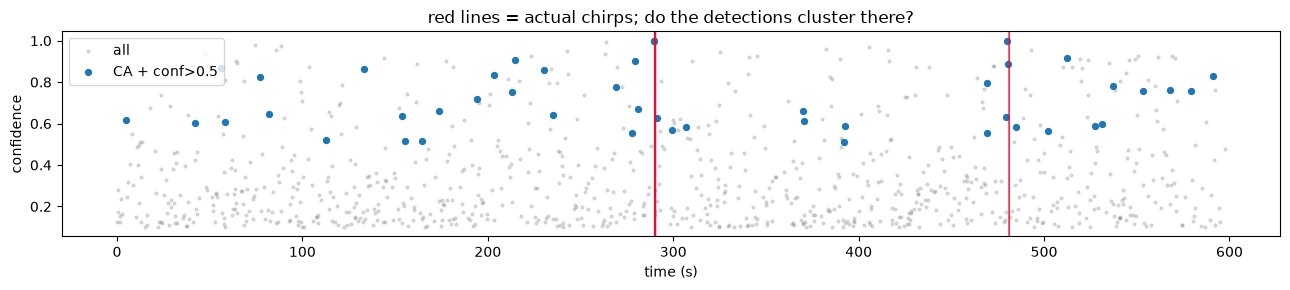

In [6]:
import numpy as np, soundfile as sf, pandas as pd, glob, os
import matplotlib.pyplot as plt

CA_SPECIES = {
    "Antrozous pallidus", "Corynorhinus townsendii", "Eptesicus fuscus",
    "Euderma maculatum", "Eumops perotis", "Idionycteris phyllotis",
    "Lasionycteris noctivagans", "Lasiurus blossevillii", "Lasiurus cinereus",
    "Lasiurus xanthinus", "Myotis californicus", "Myotis ciliolabrum",
    "Myotis evotis", "Myotis lucifugus", "Myotis thysanodes", "Myotis volans",
    "Myotis yumanensis", "Nyctinomops femorosaccus", "Nyctinomops macrotis",
    "Parastrellus hesperus", "Tadarida brasiliensis",
}

df = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
print(f"all detections:        {len(df)}")
print(f"California species:    {df['Scientific name'].isin(CA_SPECIES).sum()}")
print(f"conf > 0.5:            {(df.Confidence > 0.5).sum()}")

strict = df[df["Scientific name"].isin(CA_SPECIES) & (df.Confidence > 0.5)]
print(f"CA species AND conf>0.5: {len(strict)}\n")
print(strict.groupby("Scientific name")
            .agg(n=("Confidence", "size"), max_conf=("Confidence", "max"))
            .sort_values("n", ascending=False).to_string())

# --- do the hits coincide with real chirps? ---
N_FFT, HOP, SR = 512, 128, 384000
F_LO, F_HI = 45_000, 100_000
win = np.hanning(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, 1 / SR)
keep = np.where((freqs >= F_LO) & (freqs <= F_HI))[0]

chirp_times = []
with sf.SoundFile(FULL_WAV) as f:
    blk = int(10.0 * SR)
    b = 0
    while True:
        x = f.read(frames=blk, dtype="float64", always_2d=True)
        if len(x) < N_FFT * 4:
            break
        x = np.ascontiguousarray(x[:, 0])
        n = 1 + (len(x) - N_FFT) // HOP
        fr = np.lib.stride_tricks.as_strided(
            x, shape=(n, N_FFT), strides=(x.strides[0] * HOP, x.strides[0]))
        power = np.abs(np.fft.rfft(fr * win, axis=1)) ** 2
        d = 10 * np.log10(np.maximum(power[:, keep], 1e-20))
        e = np.percentile(d, 90, axis=1)
        hits = np.where(e > np.median(e) + 5)[0]
        if len(hits):
            for g in np.split(hits, np.where(np.diff(hits) > 3)[0] + 1):
                chirp_times.append(b * 10.0 + int(g[0]) * HOP / SR)
        b += 1
        print(f"  {b*10:5d}s  {len(chirp_times)} chirps", end="\r")

chirp_times = np.array(chirp_times)
print(f"\nenergy detector found {len(chirp_times)} chirps")

det_t = df["Start (s)"].values
if len(chirp_times):
    near = np.array([np.min(np.abs(chirp_times - t)) < 1.0 for t in det_t])
    print(f"BattyBirdNET hits within 1 s of a real chirp: {near.sum()} / {len(det_t)} "
          f"({near.mean()*100:.1f}%)")
    print(f"expected by chance: ~{min(len(chirp_times)*2/600, 1.0)*100:.1f}%")

    strict_t = strict["Start (s)"].values
    near_s = np.array([np.min(np.abs(chirp_times - t)) < 1.0 for t in strict_t])
    print(f"CA + conf>0.5 near a chirp: {near_s.sum()} / {len(strict_t)} "
          f"({near_s.mean()*100:.1f}%)")

plt.figure(figsize=(13, 3))
plt.scatter(det_t, df.Confidence, s=4, alpha=0.25, c="gray", label="all")
plt.scatter(strict["Start (s)"], strict.Confidence, s=18, c="tab:blue",
            label="CA + conf>0.5")
for t in chirp_times:
    plt.axvline(t, color="crimson", lw=0.8, alpha=0.6)
plt.xlabel("time (s)"); plt.ylabel("confidence")
plt.title("red lines = actual chirps; do the detections cluster there?")
plt.legend(); plt.tight_layout(); plt.show()

/home/jgersey/SageBat/20260414_100939.wav
600.0 s at 384000 Hz (230400000 samples)
computing overview ...
  overview 2000/2000
each overview column = 300 ms of audio
loudest bat-band moment: 289.699 s (-12.2 dB)
computing zooms ...
wrote full_recording_spectrogram.png


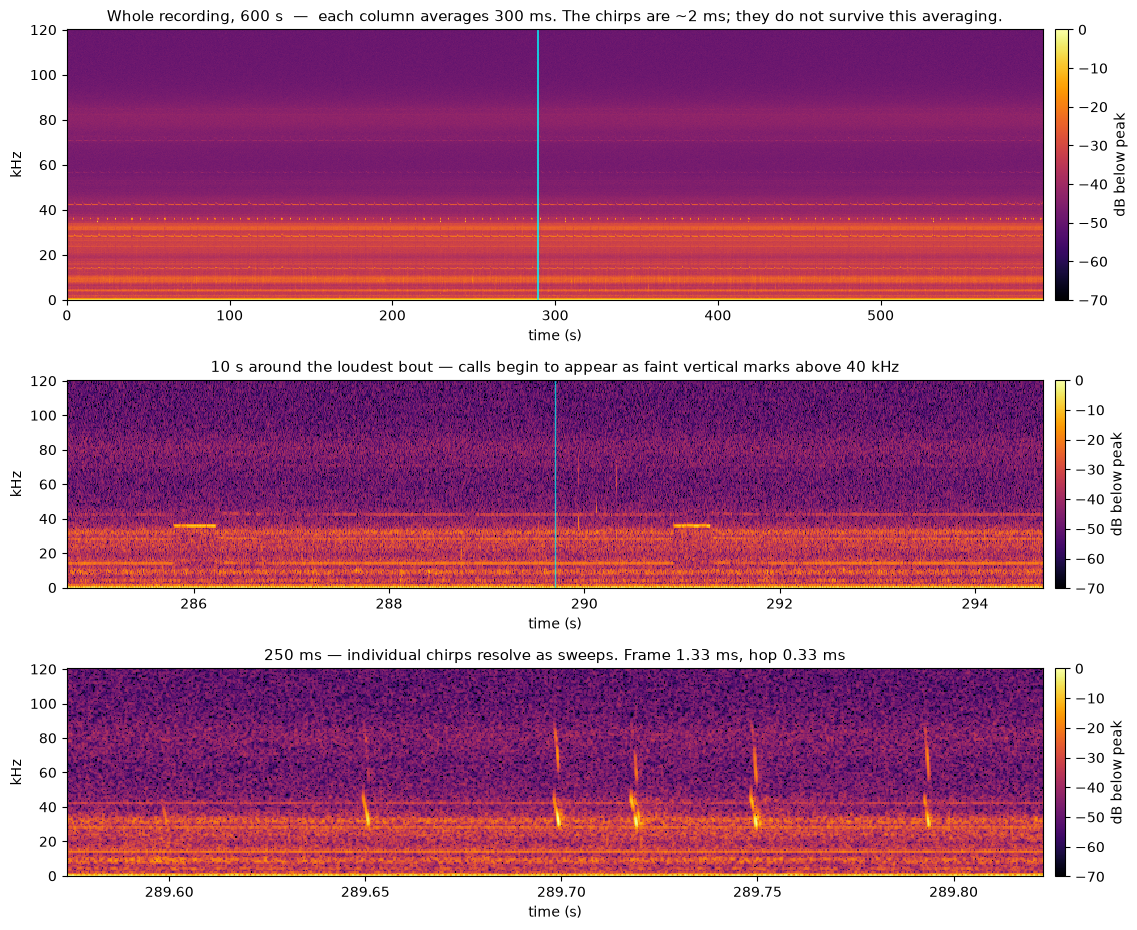


--- why the calls vanish at full scale ---
recording duration      600 s
overview columns        2000
audio per column        300 ms
typical chirp duration  ~2 ms
dilution factor         ~150x

A 2 ms call inside a column covering 300 ms contributes about 0.67% of that column's energy.
Even a call 20 dB above background lifts the column by well under 1 dB.


In [7]:
# plotting entire 10 min .wav spectrogram

"""
Plot the full 10-minute recording as a spectrogram.

The point of this figure: at whole-recording scale the bat calls are invisible.
They are ~2 ms events in a 600 s file, so at any plottable pixel width each column
covers hundreds of milliseconds and the chirps are averaged into the background.
What you see instead is the persistent insect chorus below ~45 kHz.

Three panels, at increasing zoom, make the argument:
  1. the whole 600 s
  2. a 10 s window around a bout
  3. a 0.25 s window where individual chirps resolve

Produces `full_recording_spectrogram.png`.
"""

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# =========================================================
# Configuration
# =========================================================
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"
OUT_PNG = "full_recording_spectrogram.png"

# Overview: coarse in time, since the figure is only ~2000 px wide anyway
OV_NFFT = 2048
OV_COLS = 2000          # target number of time columns for the whole file

# Zoom panels
ZOOM_NFFT = 512
ZOOM_HOP = 128

# Set these once you know where a bout is (from the energy detector).
# If left as None, the script finds the loudest 45-100 kHz moment itself.
BOUT_T = None
MID_SPAN = 10.0         # seconds, panel 2
FINE_SPAN = 0.25        # seconds, panel 3

DB_FLOOR = -70          # display range below peak
F_MAX_KHZ = 120         # top of the frequency axis


# =========================================================
# Load metadata
# =========================================================
info = sf.info(FULL_WAV)
SR = info.samplerate
N_TOTAL = info.frames
DURATION = info.duration

print(f"{FULL_WAV}")
print(f"{DURATION:.1f} s at {SR} Hz ({N_TOTAL} samples)")


# =========================================================
# Overview: one column per chunk, streamed
# =========================================================
def overview_spectrogram():
    """Average power spectrum per time column, across the whole file."""
    col_samples = N_TOTAL // OV_COLS
    if col_samples < OV_NFFT:
        raise ValueError("OV_COLS too high for this file; lower it")

    freqs = np.fft.rfftfreq(OV_NFFT, d=1 / SR)
    window = np.hanning(OV_NFFT)
    n_sub = max(1, col_samples // OV_NFFT)

    spec = np.zeros((OV_COLS, len(freqs)))

    with sf.SoundFile(FULL_WAV) as f:
        for i in range(OV_COLS):
            f.seek(i * col_samples)
            x = f.read(frames=col_samples, dtype="float64", always_2d=True)[:, 0]
            if len(x) < OV_NFFT:
                break
            x = np.ascontiguousarray(x[: n_sub * OV_NFFT])
            subs = x.reshape(n_sub, OV_NFFT)
            p = np.abs(np.fft.rfft(subs * window, axis=1)) ** 2
            spec[i] = p.mean(axis=0)
            if i % 200 == 0:
                print(f"  overview {i}/{OV_COLS}", end="\r")

    print(f"  overview {OV_COLS}/{OV_COLS}")
    db = 10 * np.log10(np.maximum(spec, spec.max() * 1e-12))
    return db - db.max(), freqs, col_samples


# =========================================================
# Zoom: plain STFT over a short window
# =========================================================
def zoom_spectrogram(t0, span):
    start = max(0, int(t0 * SR))
    n = int(span * SR)
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(start)
        x = f.read(frames=n, dtype="float64", always_2d=True)[:, 0]
    x = np.ascontiguousarray(x)

    window = np.hanning(ZOOM_NFFT)
    freqs = np.fft.rfftfreq(ZOOM_NFFT, d=1 / SR)
    n_fr = 1 + (len(x) - ZOOM_NFFT) // ZOOM_HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n_fr, ZOOM_NFFT), strides=(x.strides[0] * ZOOM_HOP, x.strides[0])
    )
    p = np.abs(np.fft.rfft(fr * window, axis=1)) ** 2
    db = 10 * np.log10(np.maximum(p, p.max() * 1e-12))
    times = start / SR + np.arange(n_fr) * ZOOM_HOP / SR
    return db - db.max(), freqs, times


# =========================================================
# Locate a bout if not supplied
# =========================================================
def find_loudest_bat_moment():
    """Time of the strongest 45-100 kHz energy, scanned coarsely."""
    nfft = 512
    window = np.hanning(nfft)
    freqs = np.fft.rfftfreq(nfft, d=1 / SR)
    keep = np.where((freqs >= 45_000) & (freqs <= 100_000))[0]

    best_t, best_v = 0.0, -np.inf
    blk = int(10.0 * SR)
    with sf.SoundFile(FULL_WAV) as f:
        b = 0
        while True:
            x = f.read(frames=blk, dtype="float64", always_2d=True)
            if len(x) < nfft * 4:
                break
            x = np.ascontiguousarray(x[:, 0])
            n_fr = 1 + (len(x) - nfft) // 128
            fr = np.lib.stride_tricks.as_strided(
                x, shape=(n_fr, nfft), strides=(x.strides[0] * 128, x.strides[0])
            )
            p = np.abs(np.fft.rfft(fr * window, axis=1)) ** 2
            e = np.percentile(10 * np.log10(np.maximum(p[:, keep], 1e-20)), 90, axis=1)
            i = int(e.argmax())
            if e[i] > best_v:
                best_v, best_t = e[i], b * 10.0 + i * 128 / SR
            b += 1
    print(f"loudest bat-band moment: {best_t:.3f} s ({best_v:.1f} dB)")
    return best_t


# =========================================================
# Build the figure
# =========================================================
print("computing overview ...")
ov_db, ov_freqs, col_samples = overview_spectrogram()
col_ms = col_samples / SR * 1000
print(f"each overview column = {col_ms:.0f} ms of audio")

bout_t = BOUT_T if BOUT_T is not None else find_loudest_bat_moment()

print("computing zooms ...")
mid_db, mid_freqs, mid_times = zoom_spectrogram(max(0, bout_t - MID_SPAN / 2), MID_SPAN)
fine_db, fine_freqs, fine_times = zoom_spectrogram(
    max(0, bout_t - FINE_SPAN / 2), FINE_SPAN
)

fig = plt.figure(figsize=(15, 11))
gs = GridSpec(3, 1, height_ratios=[1.3, 1, 1], hspace=0.35)

# --- panel 1: whole file ---
ax0 = fig.add_subplot(gs[0])
m = ov_freqs / 1000 <= F_MAX_KHZ
im0 = ax0.pcolormesh(
    np.arange(ov_db.shape[0]) * col_samples / SR,
    ov_freqs[m] / 1000, ov_db[:, m].T,
    shading="auto", cmap="inferno", vmin=DB_FLOOR, vmax=0,
)
ax0.axvline(bout_t, color="cyan", lw=1.2, alpha=0.9)
ax0.set_ylabel("kHz")
ax0.set_xlabel("time (s)")
ax0.set_title(
    f"Whole recording, {DURATION:.0f} s  —  each column averages {col_ms:.0f} ms. "
    "The chirps are ~2 ms; they do not survive this averaging.",
    fontsize=11,
)
fig.colorbar(im0, ax=ax0, label="dB below peak", pad=0.01)

# --- panel 2: 10 s ---
ax1 = fig.add_subplot(gs[1])
m = mid_freqs / 1000 <= F_MAX_KHZ
im1 = ax1.pcolormesh(
    mid_times, mid_freqs[m] / 1000, mid_db[:, m].T,
    shading="auto", cmap="inferno", vmin=DB_FLOOR, vmax=0,
)
ax1.axvline(bout_t, color="cyan", lw=1.0, alpha=0.7)
ax1.set_ylabel("kHz")
ax1.set_xlabel("time (s)")
ax1.set_title(f"{MID_SPAN:.0f} s around the loudest bout — calls begin to appear "
              "as faint vertical marks above 40 kHz", fontsize=11)
fig.colorbar(im1, ax=ax1, label="dB below peak", pad=0.01)

# --- panel 3: 0.25 s ---
ax2 = fig.add_subplot(gs[2])
m = fine_freqs / 1000 <= F_MAX_KHZ
im2 = ax2.pcolormesh(
    fine_times, fine_freqs[m] / 1000, fine_db[:, m].T,
    shading="auto", cmap="inferno", vmin=DB_FLOOR, vmax=0,
)
ax2.set_ylabel("kHz")
ax2.set_xlabel("time (s)")
ax2.set_title(f"{FINE_SPAN*1000:.0f} ms — individual chirps resolve as sweeps. "
              f"Frame {ZOOM_NFFT/SR*1000:.2f} ms, hop {ZOOM_HOP/SR*1000:.2f} ms",
              fontsize=11)
fig.colorbar(im2, ax=ax2, label="dB below peak", pad=0.01)

plt.savefig(OUT_PNG, dpi=140, bbox_inches="tight")
print(f"wrote {OUT_PNG}")
plt.show()


# =========================================================
# The numbers behind the argument
# =========================================================
print()
print("--- why the calls vanish at full scale ---")
print(f"recording duration      {DURATION:.0f} s")
print(f"overview columns        {OV_COLS}")
print(f"audio per column        {col_ms:.0f} ms")
print(f"typical chirp duration  ~2 ms")
print(f"dilution factor         ~{col_ms/2:.0f}x")
print()
print("A 2 ms call inside a column covering "
      f"{col_ms:.0f} ms contributes about "
      f"{2/col_ms*100:.2f}% of that column's energy.")
print("Even a call 20 dB above background lifts the column by well under 1 dB.")

600.0 s at 384000 Hz (230400000 samples)
computing overview ...
  overview 2000/2000
each overview column = 300 ms of audio
loudest bat-band moment: 289.699 s (-12.2 dB)
computing zooms ...
wrote full_recording_spectrogram.png


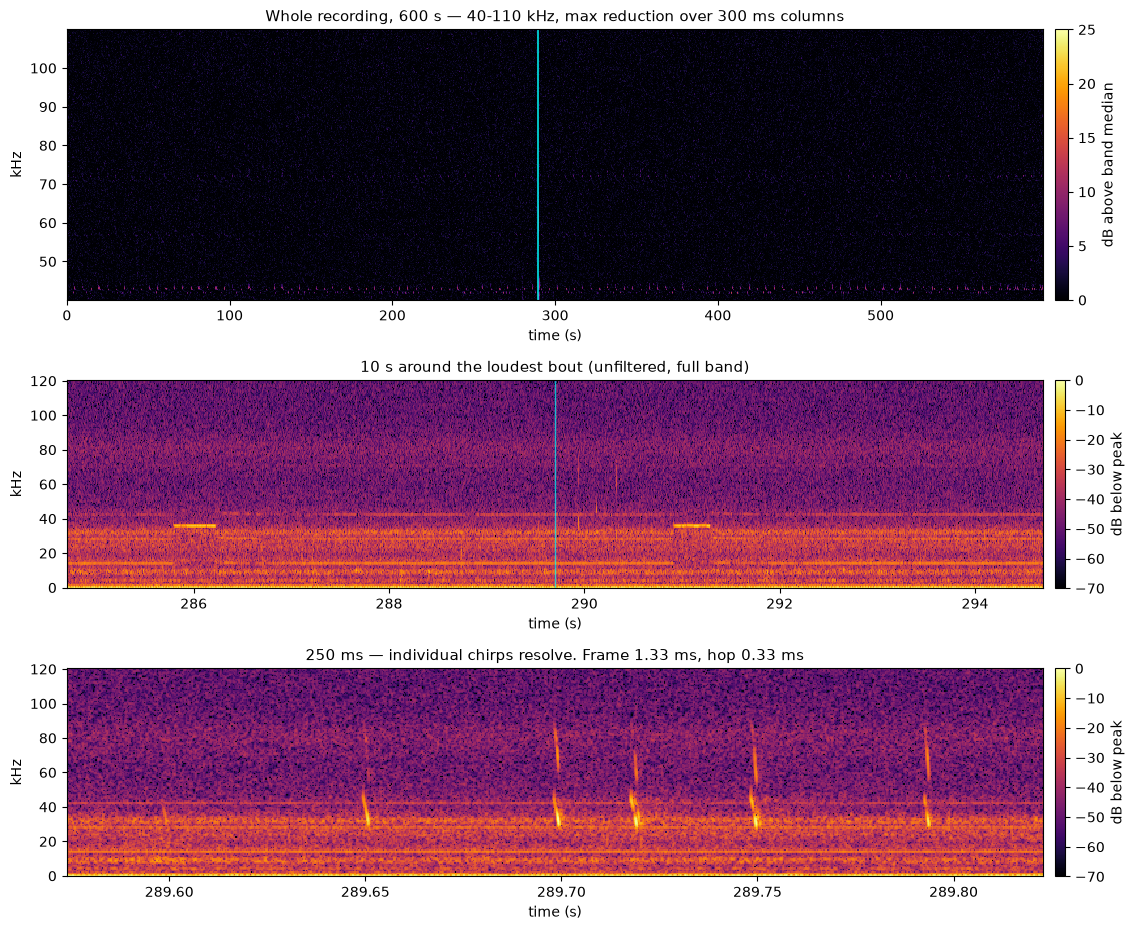


--- why calls vanish under mean reduction ---
audio per overview column  300 ms
typical chirp duration     ~2 ms
dilution factor            ~150x
a 2 ms call is 0.67% of a column's energy under 'mean';
under 'max' it sets the column value outright.


In [8]:
# =========================================================
# Full-recording spectrogram — band-limited, peak-hold
# =========================================================
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"
OUT_PNG  = "full_recording_spectrogram.png"

# ---- overview ----------------------------------------------------------
OV_NFFT     = 2048
OV_COLS     = 2000
BAND_LO     = 40_000      # Hz, compute + display range
BAND_HI     = 110_000
REDUCE      = "max"       # "max" (peak-hold), "p95", or "mean"
SUBTRACT_BG = True        # each band relative to its own median level

# ---- zooms -------------------------------------------------------------
ZOOM_NFFT = 512
ZOOM_HOP  = 128
BOUT_T    = None          # set from chirp_times, or None to auto-locate
MID_SPAN  = 10.0
FINE_SPAN = 0.25
F_MAX_KHZ = 120
DB_FLOOR  = -70

info = sf.info(FULL_WAV)
SR, N_TOTAL, DURATION = info.samplerate, info.frames, info.duration
print(f"{DURATION:.1f} s at {SR} Hz ({N_TOTAL} samples)")


def overview_spectrogram():
    col_samples = N_TOTAL // OV_COLS
    if col_samples < OV_NFFT:
        raise ValueError("OV_COLS too high for this file; lower it")

    freqs = np.fft.rfftfreq(OV_NFFT, d=1 / SR)
    keep = np.where((freqs >= BAND_LO) & (freqs <= BAND_HI))[0]
    window = np.hanning(OV_NFFT)
    n_sub = max(1, col_samples // OV_NFFT)
    spec = np.zeros((OV_COLS, len(keep)))

    with sf.SoundFile(FULL_WAV) as f:
        for i in range(OV_COLS):
            f.seek(i * col_samples)
            x = f.read(frames=col_samples, dtype="float64", always_2d=True)[:, 0]
            if len(x) < OV_NFFT:
                break
            x = np.ascontiguousarray(x[: n_sub * OV_NFFT])
            p = np.abs(np.fft.rfft(x.reshape(n_sub, OV_NFFT) * window, axis=1)) ** 2
            p = p[:, keep]
            if REDUCE == "max":
                spec[i] = p.max(axis=0)          # transients survive
            elif REDUCE == "p95":
                spec[i] = np.percentile(p, 95, axis=0)
            else:
                spec[i] = p.mean(axis=0)
            if i % 200 == 0:
                print(f"  overview {i}/{OV_COLS}", end="\r")

    print(f"  overview {OV_COLS}/{OV_COLS}")
    db = 10 * np.log10(np.maximum(spec, spec.max() * 1e-12))
    if SUBTRACT_BG:
        db = db - np.median(db, axis=0, keepdims=True)
    else:
        db = db - db.max()
    return db, freqs[keep], col_samples


def zoom_spectrogram(t0, span):
    start = max(0, int(t0 * SR))
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(start)
        x = f.read(frames=int(span * SR), dtype="float64", always_2d=True)[:, 0]
    x = np.ascontiguousarray(x)
    window = np.hanning(ZOOM_NFFT)
    freqs = np.fft.rfftfreq(ZOOM_NFFT, d=1 / SR)
    n_fr = 1 + (len(x) - ZOOM_NFFT) // ZOOM_HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n_fr, ZOOM_NFFT), strides=(x.strides[0] * ZOOM_HOP, x.strides[0]))
    p = np.abs(np.fft.rfft(fr * window, axis=1)) ** 2
    db = 10 * np.log10(np.maximum(p, p.max() * 1e-12))
    times = start / SR + np.arange(n_fr) * ZOOM_HOP / SR
    return db - db.max(), freqs, times


def find_loudest_bat_moment():
    nfft, hop = 512, 128
    window = np.hanning(nfft)
    freqs = np.fft.rfftfreq(nfft, d=1 / SR)
    keep = np.where((freqs >= 45_000) & (freqs <= 100_000))[0]
    best_t, best_v = 0.0, -np.inf
    blk = int(10.0 * SR)
    with sf.SoundFile(FULL_WAV) as f:
        b = 0
        while True:
            x = f.read(frames=blk, dtype="float64", always_2d=True)
            if len(x) < nfft * 4:
                break
            x = np.ascontiguousarray(x[:, 0])
            n_fr = 1 + (len(x) - nfft) // hop
            fr = np.lib.stride_tricks.as_strided(
                x, shape=(n_fr, nfft), strides=(x.strides[0] * hop, x.strides[0]))
            p = np.abs(np.fft.rfft(fr * window, axis=1)) ** 2
            e = np.percentile(10 * np.log10(np.maximum(p[:, keep], 1e-20)), 90, axis=1)
            i = int(e.argmax())
            if e[i] > best_v:
                best_v, best_t = e[i], b * 10.0 + i * hop / SR
            b += 1
    print(f"loudest bat-band moment: {best_t:.3f} s ({best_v:.1f} dB)")
    return best_t


print("computing overview ...")
ov_db, ov_freqs, col_samples = overview_spectrogram()
col_ms = col_samples / SR * 1000
print(f"each overview column = {col_ms:.0f} ms of audio")

bout_t = BOUT_T if BOUT_T is not None else find_loudest_bat_moment()

print("computing zooms ...")
mid_db, mid_freqs, mid_times = zoom_spectrogram(max(0, bout_t - MID_SPAN / 2), MID_SPAN)
fine_db, fine_freqs, fine_times = zoom_spectrogram(max(0, bout_t - FINE_SPAN / 2), FINE_SPAN)

fig = plt.figure(figsize=(15, 11))
gs = GridSpec(3, 1, height_ratios=[1.3, 1, 1], hspace=0.35)

# panel 1: whole file
ax0 = fig.add_subplot(gs[0])
vmin, vmax = (0, 25) if SUBTRACT_BG else (DB_FLOOR, 0)
im0 = ax0.pcolormesh(np.arange(ov_db.shape[0]) * col_samples / SR,
                     ov_freqs / 1000, ov_db.T,
                     shading="auto", cmap="inferno", vmin=vmin, vmax=vmax)
ax0.axvline(bout_t, color="cyan", lw=1.2, alpha=0.9)
ax0.set_ylabel("kHz"); ax0.set_xlabel("time (s)")
ax0.set_title(f"Whole recording, {DURATION:.0f} s — {BAND_LO/1000:.0f}-{BAND_HI/1000:.0f} kHz, "
              f"{REDUCE} reduction over {col_ms:.0f} ms columns", fontsize=11)
fig.colorbar(im0, ax=ax0, pad=0.01,
             label="dB above band median" if SUBTRACT_BG else "dB below peak")

# panel 2: 10 s
ax1 = fig.add_subplot(gs[1])
m = mid_freqs / 1000 <= F_MAX_KHZ
im1 = ax1.pcolormesh(mid_times, mid_freqs[m] / 1000, mid_db[:, m].T,
                     shading="auto", cmap="inferno", vmin=DB_FLOOR, vmax=0)
ax1.axvline(bout_t, color="cyan", lw=1.0, alpha=0.7)
ax1.set_ylabel("kHz"); ax1.set_xlabel("time (s)")
ax1.set_title(f"{MID_SPAN:.0f} s around the loudest bout (unfiltered, full band)", fontsize=11)
fig.colorbar(im1, ax=ax1, label="dB below peak", pad=0.01)

# panel 3: 250 ms
ax2 = fig.add_subplot(gs[2])
m = fine_freqs / 1000 <= F_MAX_KHZ
im2 = ax2.pcolormesh(fine_times, fine_freqs[m] / 1000, fine_db[:, m].T,
                     shading="auto", cmap="inferno", vmin=DB_FLOOR, vmax=0)
ax2.set_ylabel("kHz"); ax2.set_xlabel("time (s)")
ax2.set_title(f"{FINE_SPAN*1000:.0f} ms — individual chirps resolve. "
              f"Frame {ZOOM_NFFT/SR*1000:.2f} ms, hop {ZOOM_HOP/SR*1000:.2f} ms", fontsize=11)
fig.colorbar(im2, ax=ax2, label="dB below peak", pad=0.01)

plt.savefig(OUT_PNG, dpi=140, bbox_inches="tight")
print(f"wrote {OUT_PNG}")
plt.show()

print("\n--- why calls vanish under mean reduction ---")
print(f"audio per overview column  {col_ms:.0f} ms")
print(f"typical chirp duration     ~2 ms")
print(f"dilution factor            ~{col_ms/2:.0f}x")
print(f"a 2 ms call is {2/col_ms*100:.2f}% of a column's energy under 'mean';")
print("under 'max' it sets the column value outright.")

In [9]:
# =========================================================
# BattyBirdNET with real filtering + chirp-targeted input
# needs: FULL_WAV, chirp_times, BBN_DIR
# =========================================================
import os, glob, subprocess, tempfile
import numpy as np, soundfile as sf, pandas as pd
from scipy.signal import resample_poly, butter, sosfiltfilt

BBN_DIR = "/home/jgersey/SageBat/BattyBirdNET-Analyzer"
SR = 384000
AREA, MIN_CONF, OVERLAP = "USA", "0.05", "2.0"

def prep(y, hp=None):
    """highpass -> resample 384k->256k -> normalize"""
    if hp:
        sos = butter(8, hp, btype="highpass", fs=SR, output="sos")
        y = sosfiltfilt(sos, y)
    y = resample_poly(y, up=2, down=3)
    return y / (np.abs(y).max() + 1e-12) * 0.98

def bbn(files_dict, tag):
    """files_dict: {name: 256kHz float array} -> results DataFrame"""
    work = tempfile.mkdtemp(prefix=f"bbn_{tag}_")
    out = os.path.join(work, "results"); os.makedirs(out, exist_ok=True)
    for name, y in files_dict.items():
        sf.write(os.path.join(work, f"{name}.wav"),
                 (y * 32767).astype(np.int16), 256000, subtype="PCM_16")
    cmd = ["python3", "bat_ident.py", "--i", work, "--o", out, "--area", AREA,
           "--min_conf", MIN_CONF, "--overlap", OVERLAP, "--rtype", "csv"]
    p = subprocess.run(cmd, cwd=BBN_DIR, capture_output=True, text=True)
    csvs = glob.glob(os.path.join(out, "*.csv"))
    df = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True) if csvs else pd.DataFrame()
    n_win = len(files_dict) * 2  # ~2 windows per 1 s file at overlap 0
    print(f"\n=== {tag}: {len(df)} detections from {len(files_dict)} file(s) ===")
    if len(df):
        print(df.groupby(["Scientific name", "Common name"])
                .agg(n=("Confidence", "size"), max_conf=("Confidence", "max"))
                .sort_values("n", ascending=False).head(10).to_string())
    return df

# --- cut 1 s around each detected chirp, one file each -------------------
segs_hp, segs_raw = {}, {}
with sf.SoundFile(FULL_WAV) as f:
    for i, t in enumerate(chirp_times):
        f.seek(max(0, int((t - 0.5) * SR)))
        y = f.read(frames=SR, dtype="float64", always_2d=True)[:, 0]
        if len(y) < SR // 2:
            continue
        y = np.ascontiguousarray(y)
        segs_hp[f"chirp{i:02d}"] = prep(y, hp=35_000)
        segs_raw[f"chirp{i:02d}"] = prep(y, hp=None)

print(f"{len(segs_hp)} chirp segments")

df_raw = bbn(segs_raw, "chirps_unfiltered")
df_hp  = bbn(segs_hp,  "chirps_hp35k")

17 chirp segments

=== chirps_unfiltered: 0 detections from 17 file(s) ===

=== chirps_hp35k: 0 detections from 17 file(s) ===


In [10]:
# trying batdetect2 
from batdetect2 import api

results = api.process_file("/home/jgersey/SageBat/detected_clips/20260414_100939_det0004.wav")
for d in results["pred_dict"]["annotation"]:
    print(f"{d['start_time']:.4f}-{d['end_time']:.4f}s  "
          f"{d['low_freq']/1000:.1f}-{d['high_freq']/1000:.1f} kHz  "
          f"det_prob={d['det_prob']:.2f}  class={d['class']}")

/home/jgersey/SageBat/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.0245-0.0293s  27.2-41.0 kHz  det_prob=0.04  class=Plecotus auritus
0.0265-0.0333s  36.6-41.9 kHz  det_prob=0.10  class=Barbastellus barbastellus
0.0305-0.0361s  26.3-37.3 kHz  det_prob=0.03  class=Plecotus auritus
0.0505-0.0563s  27.2-38.4 kHz  det_prob=0.03  class=Plecotus auritus
0.0555-0.0615s  38.4-47.6 kHz  det_prob=0.03  class=Barbastellus barbastellus
0.0605-0.0669s  27.2-41.6 kHz  det_prob=0.03  class=Plecotus auritus
0.0865-0.1163s  93.4-111.0 kHz  det_prob=0.03  class=Rhinolophus hipposideros
0.0875-0.0936s  28.0-36.3 kHz  det_prob=0.03  class=Plecotus auritus
0.0955-0.1013s  27.2-39.1 kHz  det_prob=0.03  class=Plecotus auritus
0.1345-0.1400s  27.2-38.0 kHz  det_prob=0.03  class=Plecotus auritus
0.1545-0.1594s  27.2-37.0 kHz  det_prob=0.04  class=Plecotus auritus
0.1635-0.1686s  26.3-44.6 kHz  det_prob=0.03  class=Plecotus auritus
0.1655-0.1708s  39.2-49.2 kHz  det_prob=0.06  class=Barbastellus barbastellus
0.1755-0.1826s  41.8-47.5 kHz  det_prob=0.03  class=Barbastellus ba

In [4]:
"""
SageBat -> NABat ML, self-contained.

Detects chirps in the full recording, groups them into bouts, writes one WAV per
bout, classifies each with NABat ML, and aggregates the per-pulse predictions.

No session state required - run after a kernel restart.

Environment notes (both matter):
  * CUDA_VISIBLE_DEVICES=-1 - TensorFlow has no CUDA kernels for Thor
    (compute capability 11.0a); it crashes on the first GPU op otherwise.
  * MPLBACKEND is stripped and forced to Agg - Jupyter exports
    'module://matplotlib_inline.backend_inline', the conda env lacks that
    backend, and Keras 3 imports matplotlib at import time, so the subprocess
    dies before any bat code runs.
"""

import os
import re
import subprocess

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt

# =========================================================
# Configuration
# =========================================================

ENV = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
ENV.update(CUDA_VISIBLE_DEVICES="-1", MPLBACKEND="Agg",
           TF_USE_LEGACY_KERAS="1", TF_CPP_MIN_LOG_LEVEL="2") 
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"
NABAT_DIR = "/home/jgersey/SageBat/nabat-ml"
PYTHON = os.path.expanduser("~/miniconda3/envs/nabat/bin/python")
BOUT_DIR = "/home/jgersey/SageBat/bouts"

# detection
N_FFT, HOP = 512, 128
F_LO, F_HI = 45_000, 100_000
PCTL = 90
THRESH_DB = 5
MIN_GAP = 3              # frames between separate calls

# bouts
BOUT_GAP_S = 1.0         # silence longer than this starts a new bout
BOUT_PAD_S = 0.75        # context added each side

TIMEOUT_S = 900

# Strip the notebook's matplotlib backend, then force a headless one.
ENV = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
ENV.update(CUDA_VISIBLE_DEVICES="-1", MPLBACKEND="Agg", TF_CPP_MIN_LOG_LEVEL="2")

PULSE_RE = re.compile(
    r"pulse_(\d+)\s+max class\s+(\d+)\((\w+)\),\s+score\s+([0-9.eE+-]+)"
)

CA_CODES = {
    "ANPA", "COTO", "EPFU", "EUMA", "EUPE", "IDPH", "LABL", "LACI", "LANO",
    "LAXA", "MYCA", "MYCI", "MYEV", "MYLU", "MYTH", "MYVO", "MYYU", "NYFE",
    "NYMA", "PAHE", "TABR",
}

INFO = {  # code: (common name, approx peak freq kHz)
    "ANPA": ("pallid bat", "25-45"), "COTO": ("Townsend's big-eared", "20-45"),
    "EPFU": ("big brown", "23-40"), "EUMA": ("spotted bat", "8-18"),
    "EUPE": ("western mastiff", "8-16"), "IDPH": ("Allen's big-eared", "15-45"),
    "LABL": ("western red", "35-55"), "LACI": ("hoary", "16-30"),
    "LANO": ("silver-haired", "24-40"), "LAXA": ("western yellow", "30-45"),
    "MYCA": ("California myotis", "45-70"), "MYCI": ("western small-footed", "38-60"),
    "MYEV": ("long-eared myotis", "35-60"), "MYLU": ("little brown", "38-60"),
    "MYTH": ("fringed myotis", "35-60"), "MYVO": ("long-legged myotis", "38-60"),
    "MYYU": ("Yuma myotis", "45-70"), "NYFE": ("pocketed free-tailed", "18-30"),
    "NYMA": ("big free-tailed", "10-20"), "PAHE": ("canyon bat", "42-60"),
    "TABR": ("Mexican free-tailed", "20-40"),
}


# =========================================================
# 1. Detect chirps
# =========================================================
info = sf.info(FULL_WAV)
SR = info.samplerate
print(f"{os.path.basename(FULL_WAV)}: {info.duration:.1f} s at {SR} Hz")

WINDOW = np.hanning(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, d=1 / SR)
keep = np.where((freqs >= F_LO) & (freqs <= F_HI))[0]

chirp_times = []
BLK = int(10.0 * SR)

with sf.SoundFile(FULL_WAV) as f:
    b = 0
    while True:
        x = f.read(frames=BLK, dtype="float64", always_2d=True)
        if len(x) < N_FFT * 4:
            break
        x = np.ascontiguousarray(x[:, 0])
        n = 1 + (len(x) - N_FFT) // HOP
        fr = np.lib.stride_tricks.as_strided(
            x, shape=(n, N_FFT), strides=(x.strides[0] * HOP, x.strides[0]))
        power = np.abs(np.fft.rfft(fr * WINDOW, axis=1)) ** 2
        d = 10 * np.log10(np.maximum(power[:, keep], 1e-20))
        e = np.percentile(d, PCTL, axis=1)
        hits = np.where(e > np.median(e) + THRESH_DB)[0]
        if len(hits):
            for g in np.split(hits, np.where(np.diff(hits) > MIN_GAP)[0] + 1):
                c = int(g[np.argmax(e[g])])
                chirp_times.append(b * 10.0 + c * HOP / SR)
        b += 1
        print(f"  scanned {b*10:5d}s   {len(chirp_times)} chirps", end="\r")

chirp_times = np.array(sorted(chirp_times))
print(f"\n{len(chirp_times)} chirps detected")
if len(chirp_times) == 0:
    raise SystemExit("no chirps found - lower THRESH_DB")
print("times (s):", np.round(chirp_times, 2).tolist())


# =========================================================
# 2. Group into bouts
# =========================================================
bout_id = np.concatenate([[0], np.cumsum(np.diff(chirp_times) > BOUT_GAP_S)])
n_bouts = int(bout_id.max()) + 1
print(f"\n{n_bouts} bout(s)")

os.makedirs(BOUT_DIR, exist_ok=True)
bouts = []

for bi in range(n_bouts):
    ts = chirp_times[bout_id == bi]
    t0 = max(0.0, ts.min() - BOUT_PAD_S)
    t1 = min(info.duration, ts.max() + BOUT_PAD_S)
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(int(t0 * SR))
        y = f.read(frames=int((t1 - t0) * SR), dtype="float32", always_2d=True)[:, 0]
    path = os.path.join(BOUT_DIR, f"bout_{bi:02d}_t{t0:07.2f}.wav")
    # native rate, no filtering - NABat ML extracts pulses itself
    sf.write(path, y, SR, subtype="PCM_16")
    bouts.append(dict(bout=bi, path=path, t0=t0, t1=t1,
                      n_chirps=len(ts), dur=t1 - t0))
    print(f"  bout {bi}: {t0:7.2f}-{t1:7.2f}s  "
          f"({t1-t0:5.2f}s, {len(ts)} chirps)")


# =========================================================
# 3. Classify
# =========================================================
print("\nclassifying ...")
rows, failures = [], []

for bt in bouts:
    out_dir = os.path.join(NABAT_DIR, "classify", f"bout_{bt['bout']:02d}")
    os.makedirs(out_dir, exist_ok=True)
    cmd = [PYTHON, "nabat_ml_cli.py", "-p", out_dir, "-f", bt["path"]]
    try:
        p = subprocess.run(cmd, cwd=NABAT_DIR, capture_output=True,
                           text=True, timeout=TIMEOUT_S, env=ENV)
    except subprocess.TimeoutExpired:
        failures.append((bt["bout"], "timeout"))
        print(f"  bout {bt['bout']}: TIMEOUT")
        continue

    hits = PULSE_RE.findall(p.stdout)
    if not hits:
        failures.append((bt["bout"], p.stderr[-400:] or p.stdout[-400:]))
        print(f"  bout {bt['bout']}: no pulses "
              f"(returncode {p.returncode})")
        continue

    for offset, cid, code, score in hits:
        rows.append(dict(bout=bt["bout"], t0=bt["t0"], pulse=int(offset),
                         class_id=int(cid), code=code, score=float(score)))
    top = pd.Series([h[2] for h in hits]).value_counts().idxmax()
    print(f"  bout {bt['bout']}: {len(hits):3d} pulses, top {top}")

if failures:
    print(f"\n{len(failures)} failure(s). First:")
    print(" ", failures[0][1][:600])

if not rows:
    raise SystemExit(
        "\nNo pulses classified in any bout.\n"
        "If the error above mentions matplotlib or CUDA, the ENV dict needs "
        "adjusting. If NABat ML simply found no bat pulses, that is a real "
        "result: its pulse extractor does not recognize these calls."
    )

df = pd.DataFrame(rows)
df["in_ca"] = df["code"].isin(CA_CODES)
df["common"] = df["code"].map(lambda c: INFO.get(c, ("(out of range)", "?"))[0])
df.to_csv("nabat_ml_results.csv", index=False)


# =========================================================
# 4. Results
# =========================================================
print("\n" + "=" * 62)
print(f"{len(df)} pulses across {df.bout.nunique()} bout(s)")

print("\n--- all predictions ---")
summary = (df.groupby("code")
             .agg(pulses=("score", "size"), mean_score=("score", "mean"),
                  max_score=("score", "max"), bouts=("bout", "nunique"))
             .sort_values("pulses", ascending=False))
summary["common"] = [INFO.get(c, ("(out of range)", "?"))[0] for c in summary.index]
summary["exp_khz"] = [INFO.get(c, ("?", "?"))[1] for c in summary.index]
print(summary.to_string())

print(f"\nCalifornia species: {int(df.in_ca.sum())}/{len(df)} pulses "
      f"({df.in_ca.mean()*100:.0f}%)")
print("The model applies no geographic prior, so a high out-of-range fraction")
print("means the predictions are unreliable.")

ca = df[df.in_ca]
if len(ca):
    print("\n--- score-weighted consensus, CA species only ---")
    w = ca.groupby("code")["score"].sum().sort_values(ascending=False)
    total = w.sum()
    for code, val in w.items():
        name, exp = INFO.get(code, ("?", "?"))
        flag = "" if exp == "?" else f"   expected {exp} kHz"
        print(f"  {code} ({name}): {val/total*100:5.1f}% of weight{flag}")

    top = w.index[0]
    print(f"\ntop: {top} ({INFO[top][0]}), expected peak {INFO[top][1]} kHz")
    print("Your chirps sweep roughly 38-68 kHz. If the expected range for the")
    print("top species excludes that, the prediction is wrong regardless of score.")
else:
    print("\nNo California species predicted - all output is out of range.")

# --- figure ---
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
summary["pulses"].head(10).plot.barh(ax=ax[0], color="tab:blue")
ax[0].set_xlabel("pulses"); ax[0].set_title("predictions"); ax[0].invert_yaxis()
ax[1].scatter(df["score"], df["code"].astype("category").cat.codes,
              c=df["in_ca"].map({True: "tab:green", False: "tab:red"}), s=18)
ax[1].set_yticks(range(df["code"].nunique()))
ax[1].set_yticklabels(sorted(df["code"].unique()))
ax[1].set_xlabel("score"); ax[1].set_title("green = California species")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

20260414_100939.wav: 600.0 s at 384000 Hz
  scanned   600s   17 chirps
17 chirps detected
times (s): [289.65, 289.7, 289.72, 289.75, 289.79, 289.94, 290.02, 290.09, 290.13, 290.17, 290.2, 290.28, 290.33, 290.38, 480.68, 480.83, 481.01]

2 bout(s)
  bout 0:  288.90- 291.13s  ( 2.23s, 14 chirps)
  bout 1:  479.93- 481.76s  ( 1.83s, 3 chirps)

classifying ...
  bout 0: no pulses (returncode 1)
  bout 1: no pulses (returncode 1)

2 failure(s). First:
  ` files, legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(/home/jgersey/SageBat/nabat-ml/prediction/tf-models/m-1, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).



SystemExit: 
No pulses classified in any bout.
If the error above mentions matplotlib or CUDA, the ENV dict needs adjusting. If NABat ML simply found no bat pulses, that is a real result: its pulse extractor does not recognize these calls.

In [5]:
import numpy as np, soundfile as sf

FULL_LO, FULL_HI = 10_000, 100_000     # full band, not the 45 kHz cut
N_FFT, HOP = 512, 128

validated = [289.67, 289.73, 289.79, 289.82, 290.15,
             290.18, 290.21, 290.30, 290.36]

freqs = np.fft.rfftfreq(N_FFT, 1/SR)
keep = np.where((freqs >= FULL_LO) & (freqs <= FULL_HI))[0]
win = np.hanning(N_FFT)

for t in validated:
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(int((t - 0.010) * SR))
        x = np.ascontiguousarray(
            f.read(frames=int(0.020 * SR), dtype="float64", always_2d=True)[:, 0])
    n = 1 + (len(x) - N_FFT) // HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0]*HOP, x.strides[0]))
    p = np.abs(np.fft.rfft(fr * win, axis=1))**2
    d = 10*np.log10(np.maximum(p[:, keep], 1e-20))
    d -= d.max()

    active = d.max(axis=1) > -25
    if active.sum() < 2:
        continue
    peak = freqs[keep][d[active].argmax(axis=1)] / 1000
    hi, lo = peak[0], peak[-1]
    dur_ms = active.sum() * HOP / SR * 1000
    char = np.median(peak[-max(1, len(peak)//3):])   # flattest terminal portion

    print(f"t={t:7.2f}  start {hi:5.1f}  end {lo:5.1f}  "
          f"char {char:5.1f} kHz  dur {dur_ms:4.1f} ms")

print("\nreference characteristic frequencies:")
print("  COTO  ~25-30 kHz, sweeps from ~60, 3-6 ms, very low amplitude")
print("  ANPA  ~30-35 kHz, sweeps from ~55, 3-5 ms")
print("  MYEV  ~40-45 kHz, sweeps from ~85, 3-5 ms")

t= 289.67  start  14.2  end  14.2  char  14.2 kHz  dur 19.0 ms
t= 289.73  start  34.5  end  32.2  char  14.2 kHz  dur 19.0 ms
t= 289.79  start  14.2  end  30.8  char  30.0 kHz  dur 19.0 ms
t= 289.82  start  14.2  end  14.2  char  14.2 kHz  dur 19.0 ms
t= 290.15  start  32.2  end  28.5  char  14.2 kHz  dur 19.0 ms
t= 290.18  start  32.2  end  14.2  char  14.2 kHz  dur 19.0 ms
t= 290.21  start  32.2  end  14.2  char  14.2 kHz  dur 19.0 ms
t= 290.30  start  14.2  end  14.2  char  14.2 kHz  dur 19.0 ms
t= 290.36  start  15.8  end  14.2  char  14.2 kHz  dur 19.0 ms

reference characteristic frequencies:
  COTO  ~25-30 kHz, sweeps from ~60, 3-6 ms, very low amplitude
  ANPA  ~30-35 kHz, sweeps from ~55, 3-5 ms
  MYEV  ~40-45 kHz, sweeps from ~85, 3-5 ms


In [6]:
import numpy as np, soundfile as sf

N_FFT, HOP = 512, 128
BAND_LO, BAND_HI = 12_000, 100_000
CONTEXT_S = 0.4          # window for estimating the background
CALL_MS = 12             # search window around each detection
RESID_DB = 6             # dB above background to count as call energy

freqs = np.fft.rfftfreq(N_FFT, 1/SR)
keep = np.where((freqs >= BAND_LO) & (freqs <= BAND_HI))[0]
fk = freqs[keep] / 1000
win = np.hanning(N_FFT)

def spec(x):
    n = 1 + (len(x) - N_FFT) // HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0]*HOP, x.strides[0]))
    p = np.abs(np.fft.rfft(fr * win, axis=1))**2
    return 10*np.log10(np.maximum(p[:, keep], 1e-20))

validated = [289.67, 289.73, 289.79, 289.82, 290.15,
             290.18, 290.21, 290.30, 290.36]

print(f"{'time':>8} {'start':>7} {'end':>7} {'char':>7} {'dur':>6} {'SNR':>6}")
for t in validated:
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(max(0, int((t - CONTEXT_S/2) * SR)))
        x = np.ascontiguousarray(
            f.read(frames=int(CONTEXT_S*SR), dtype="float64", always_2d=True)[:, 0])

    d = spec(x)
    bg = np.median(d, axis=0, keepdims=True)     # stationary chorus
    r = d - bg                                    # transients only

    centre = d.shape[0] // 2
    half = int(CALL_MS/1000 * SR / HOP / 2)
    lo, hi = max(0, centre-half), min(d.shape[0], centre+half)
    seg = r[lo:hi]

    per_frame = seg.max(axis=1)
    active = per_frame > RESID_DB
    if active.sum() < 2:
        print(f"{t:8.2f}   no call energy above background")
        continue

    idx = np.where(active)[0]
    peaks = fk[seg[idx].argmax(axis=1)]
    dur_ms = len(idx) * HOP / SR * 1000
    char = np.median(peaks[-max(1, len(peaks)//3):])

    print(f"{t:8.2f} {peaks[0]:7.1f} {peaks[-1]:7.1f} {char:7.1f} "
          f"{dur_ms:6.1f} {per_frame[idx].max():6.1f}")

print("\nreference (characteristic frequency, the flattened terminal portion):")
print("  COTO  ~25-30 kHz, sweeps from ~60, 3-6 ms, very quiet")
print("  ANPA  ~30-35 kHz, sweeps from ~55, 3-5 ms")
print("  MYEV  ~40-45 kHz, sweeps from ~85, 3-5 ms")

    time   start     end    char    dur    SNR
  289.67    44.2    53.2    78.0   12.0   11.3
  289.73    78.8    89.2    58.1   12.0   14.0
  289.79    27.0    23.2    53.2   12.0   29.7
  289.82    79.5    35.2    64.9   12.0   11.6
  290.15    45.8    83.2    63.8   11.7   10.7
  290.18    98.2    84.8    67.5   11.3   10.5
  290.21    39.8    90.8    71.2   12.0   11.6
  290.30    38.2    99.8    58.9   12.0   10.9
  290.36    87.0    63.0    65.2   11.7   12.4

reference (characteristic frequency, the flattened terminal portion):
  COTO  ~25-30 kHz, sweeps from ~60, 3-6 ms, very quiet
  ANPA  ~30-35 kHz, sweeps from ~55, 3-5 ms
  MYEV  ~40-45 kHz, sweeps from ~85, 3-5 ms


600.0 s at 384000 Hz
band 10-100 kHz, 120 bins, 750 Hz each

1 tonal line(s) detected:
   14.25 kHz   + 7.7 dB above local floor

wrote chorus_notch_check.png


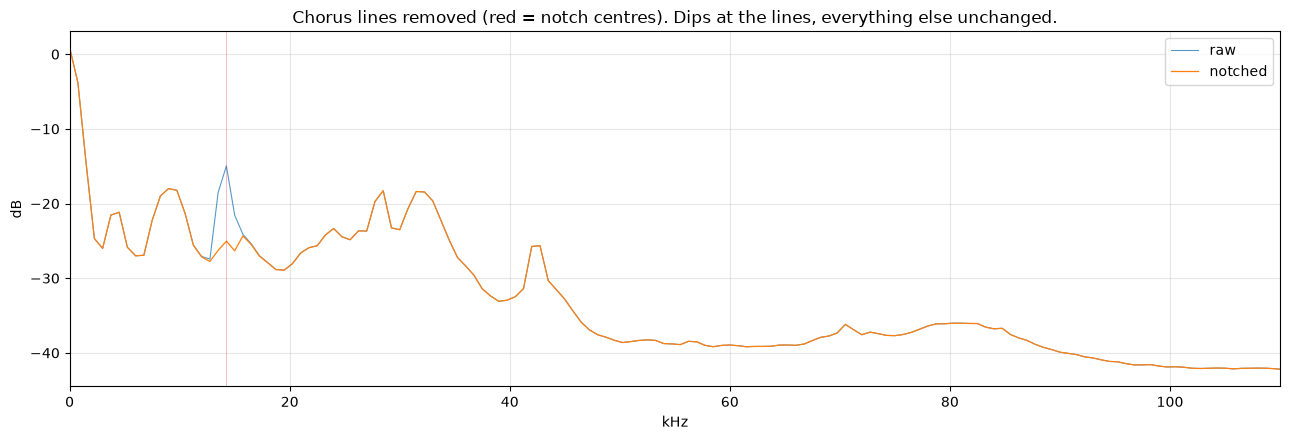

wrote calls_notched.png


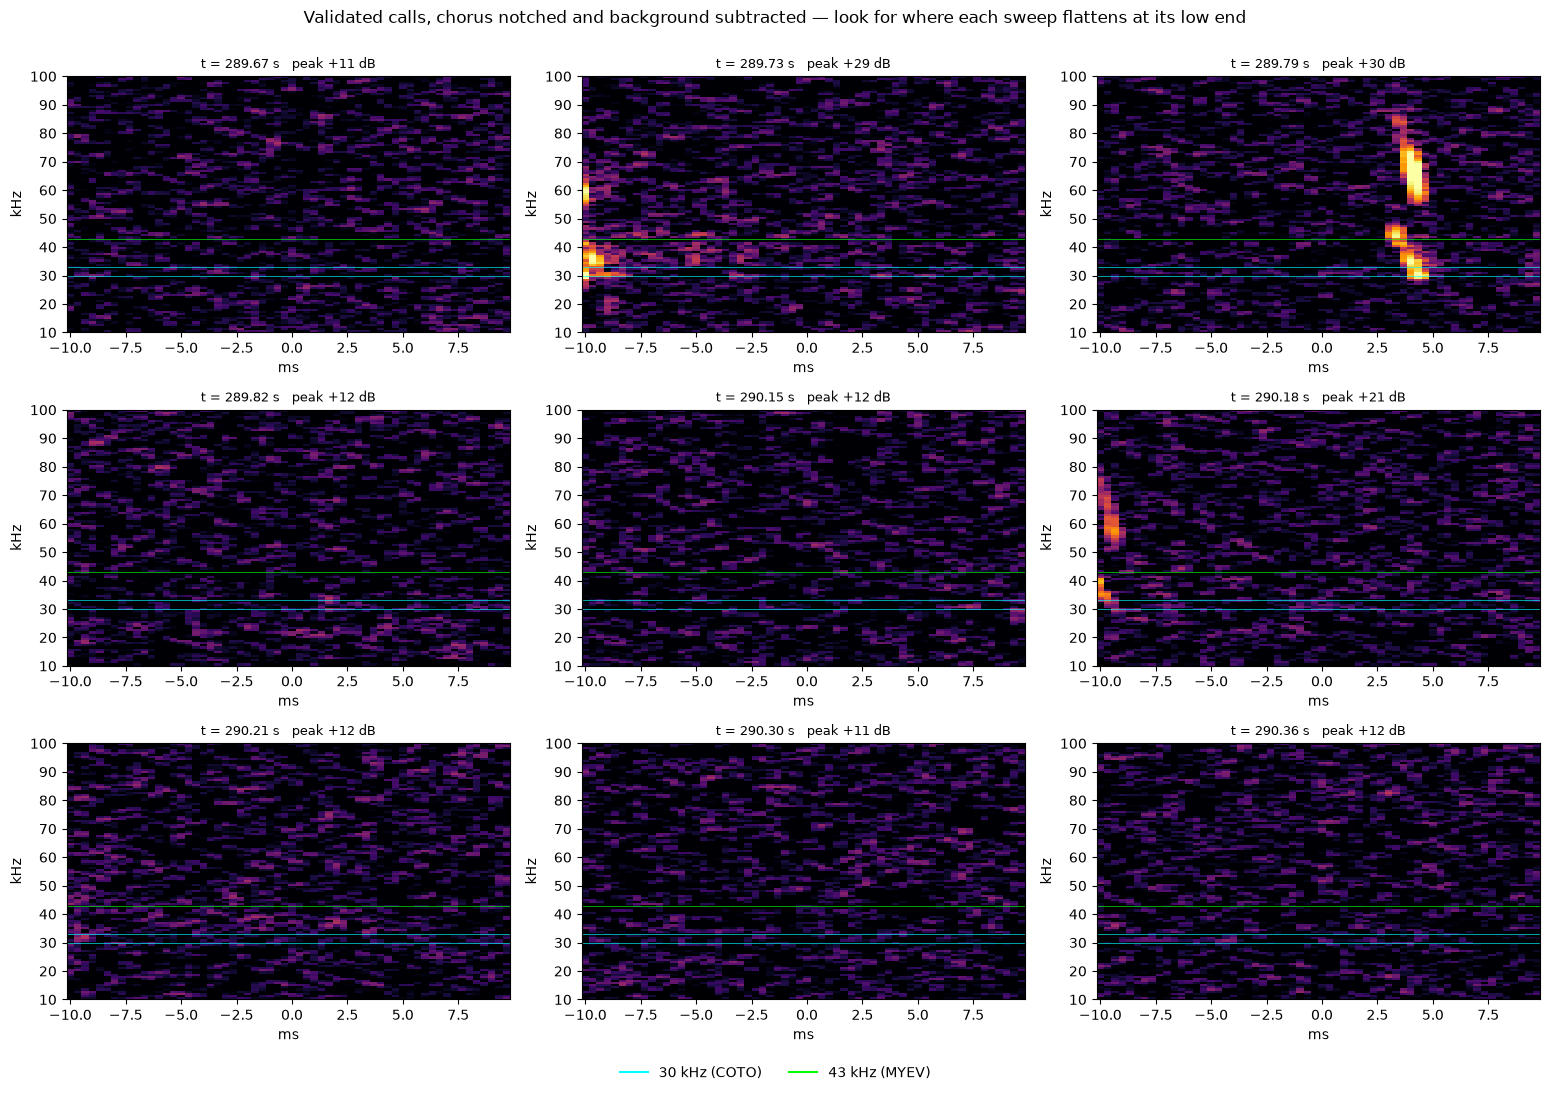


How to read the second figure
-----------------------------
Colour is dB above the local background, so anything visible is transient.

  * A bat call is a downward diagonal streak lasting 2-6 ms.
  * The characteristic frequency is where it FLATTENS near the bottom.
      near the cyan line  -> Corynorhinus townsendii (matches the cave)
      near the lime line  -> a Myotis
  * Gaps at the notch frequencies are expected; read the approach to the
    plateau rather than the plateau itself where they overlap.
  * If no coherent sweep appears in most panels, the defensible claim is
    "bat activity detected, 17 calls in two bouts, species indeterminate."



In [7]:
"""
Inspect the SageBat calls with the tonal chorus notched out.

Why notches rather than a highpass: the chorus is not broadband, it is a set of
narrow tonal lines (a ~14 kHz fundamental plus harmonics). A highpass at 45 kHz
removes them but also removes COTO's diagnostic characteristic frequency, which
sits at 25-30 kHz - inside the chorus band. Notching each line individually
keeps the space between them.

Outputs two figures:
  1. spectrum before/after notching, to verify the lines were found
  2. nine background-subtracted spectrograms, one per validated call

Read the second figure for where each sweep FLATTENS at its low end. That
terminal plateau is the characteristic frequency and is what separates the
candidate species:
    COTO ~25-30 kHz    ANPA ~30-35 kHz    MYEV ~40-45 kHz

Automated parameter extraction is deliberately not attempted here - at ~10 dB
SNR it produced nonsense (ascending sweeps, durations pinned to the window).
Nine calls is few enough to read by eye, which is what a bat biologist would do.
"""

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, iirnotch, filtfilt

# =========================================================
# Configuration
# =========================================================
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"

# Times of the calls confirmed by both the energy detector and NABat ML
VALIDATED = [289.67, 289.73, 289.79, 289.82, 290.15,
             290.18, 290.21, 290.30, 290.36]

N_FFT, HOP = 512, 128
BAND_LO, BAND_HI = 10_000, 100_000     # full band - do NOT cut below 45 kHz

# chorus line detection
SURVEY_T = 289.0          # a few seconds spanning the bout
SURVEY_S = 3.0
LINE_PROMINENCE_DB = 6    # how far a line must stand above its neighbours
LINE_MAX_WIDTH_HZ = 3000  # wider than this is not a tonal line
NOTCH_Q = 35              # higher = narrower notch

# display
CONTEXT_S = 0.4           # audio loaded per call (background estimate)
VIEW_MS = 20              # width of each panel
VMAX_DB = 25              # colour ceiling, dB above background

REF_LINES = {"COTO ~30": 30, "ANPA ~33": 33, "MYEV ~43": 43}

FIG1 = "chorus_notch_check.png"
FIG2 = "calls_notched.png"


# =========================================================
# Helpers
# =========================================================
info = sf.info(FULL_WAV)
SR = info.samplerate
WINDOW = np.hanning(N_FFT)
FREQS = np.fft.rfftfreq(N_FFT, d=1 / SR)
KEEP = np.where((FREQS >= BAND_LO) & (FREQS <= BAND_HI))[0]
FK = FREQS[KEEP] / 1000

print(f"{info.duration:.1f} s at {SR} Hz")
print(f"band {BAND_LO/1000:.0f}-{BAND_HI/1000:.0f} kHz, {len(KEEP)} bins, "
      f"{FREQS[1]-FREQS[0]:.0f} Hz each")


def read_at(t, span):
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(max(0, int((t - span / 2) * SR)))
        x = f.read(frames=int(span * SR), dtype="float64", always_2d=True)[:, 0]
    return np.ascontiguousarray(x)


def stft_db(x, band=True):
    """Framed power spectrum in dB. Parenthesised to avoid ** / [] precedence."""
    n = 1 + (len(x) - N_FFT) // HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0] * HOP, x.strides[0])
    )
    power = np.abs(np.fft.rfft(fr * WINDOW, axis=1)) ** 2
    if band:
        power = power[:, KEEP]
    return 10 * np.log10(np.maximum(power, 1e-20))


# =========================================================
# 1. Find the tonal chorus lines
# =========================================================
survey = read_at(SURVEY_T, SURVEY_S)
lta = stft_db(survey, band=False).mean(axis=0)

# smooth baseline, so peaks are judged against the local floor
kernel = max(3, int(2000 / (FREQS[1] - FREQS[0])) | 1)
baseline = np.convolve(lta, np.ones(kernel) / kernel, mode="same")
excess = lta - baseline

max_width_bins = LINE_MAX_WIDTH_HZ / (FREQS[1] - FREQS[0])
peaks, props = find_peaks(excess, prominence=LINE_PROMINENCE_DB,
                          width=(None, max_width_bins))

lines = FREQS[peaks]
lines = lines[(lines > 5_000) & (lines < SR / 2 * 0.95)]

print(f"\n{len(lines)} tonal line(s) detected:")
for f0, pr in zip(lines, props["prominences"][:len(lines)]):
    print(f"  {f0/1000:6.2f} kHz   +{pr:4.1f} dB above local floor")

if len(lines) == 0:
    print("  none found - lower LINE_PROMINENCE_DB, or the chorus is broadband")


# =========================================================
# 2. Notch filter
# =========================================================
def denotch(x, lines=lines, q=NOTCH_Q):
    y = x.astype(np.float64).copy()
    for f0 in lines:
        if 0 < f0 < SR / 2:
            b, a = iirnotch(f0, q, fs=SR)
            y = filtfilt(b, a, y)
    return y


# --- verification figure ---
notched = denotch(survey)

fig, ax = plt.subplots(figsize=(13, 4.5))
for label, sig, style in [("raw", survey, dict(lw=0.8, alpha=0.75)),
                          ("notched", notched, dict(lw=0.9))]:
    p = (np.abs(np.fft.rfft(
        np.lib.stride_tricks.as_strided(
            sig, shape=(1 + (len(sig) - N_FFT) // HOP, N_FFT),
            strides=(sig.strides[0] * HOP, sig.strides[0])) * WINDOW,
        axis=1)) ** 2).mean(axis=0)
    ax.plot(FREQS / 1000, 10 * np.log10(np.maximum(p, 1e-20)),
            label=label, **style)

for f0 in lines:
    ax.axvline(f0 / 1000, color="crimson", lw=0.5, alpha=0.4)
ax.set_xlim(0, 110)
ax.set_xlabel("kHz"); ax.set_ylabel("dB")
ax.set_title("Chorus lines removed (red = notch centres). "
             "Dips at the lines, everything else unchanged.")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG1, dpi=140, bbox_inches="tight")
print(f"\nwrote {FIG1}")
plt.show()


# =========================================================
# 3. The calls
# =========================================================
n_calls = len(VALIDATED)
ncols = 3
nrows = int(np.ceil(n_calls / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows),
                         squeeze=False)
half = int(VIEW_MS / 1000 * SR / HOP / 2)

for k, t in enumerate(VALIDATED):
    ax = axes[k // ncols][k % ncols]

    x = denotch(read_at(t, CONTEXT_S))
    d = stft_db(x)
    resid = d - np.median(d, axis=0, keepdims=True)   # kill anything stationary

    c = resid.shape[0] // 2
    seg = resid[max(0, c - half):c + half]
    tm = (np.arange(seg.shape[0]) - seg.shape[0] / 2) * HOP / SR * 1000

    im = ax.pcolormesh(tm, FK, seg.T, shading="auto", cmap="inferno",
                       vmin=0, vmax=VMAX_DB)
    for label, f0 in REF_LINES.items():
        ax.axhline(f0, lw=0.7, alpha=0.65,
                   color="cyan" if f0 < 35 else "lime")
    ax.set_title(f"t = {t:.2f} s   peak +{seg.max():.0f} dB", fontsize=9)
    ax.set_xlabel("ms"); ax.set_ylabel("kHz")
    ax.set_ylim(BAND_LO / 1000, BAND_HI / 1000)

for k in range(n_calls, nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")

handles = [plt.Line2D([], [], color="cyan", lw=1.5, label="30 kHz (COTO)"),
           plt.Line2D([], [], color="lime", lw=1.5, label="43 kHz (MYEV)")]
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False)
fig.suptitle("Validated calls, chorus notched and background subtracted — "
             "look for where each sweep flattens at its low end", y=1.00)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(FIG2, dpi=140, bbox_inches="tight")
print(f"wrote {FIG2}")
plt.show()


# =========================================================
# Reading guide
# =========================================================
print("""
How to read the second figure
-----------------------------
Colour is dB above the local background, so anything visible is transient.

  * A bat call is a downward diagonal streak lasting 2-6 ms.
  * The characteristic frequency is where it FLATTENS near the bottom.
      near the cyan line  -> Corynorhinus townsendii (matches the cave)
      near the lime line  -> a Myotis
  * Gaps at the notch frequencies are expected; read the approach to the
    plateau rather than the plateau itself where they overlap.
  * If no coherent sweep appears in most panels, the defensible claim is
    "bat activity detected, 17 calls in two bouts, species indeterminate."
""")

600.0 s at 384000 Hz

detecting ...
17 chirps, SNR 5-23 dB (median 12)

1 chorus line(s): 14.2 kHz
2 bout(s)
  bout 0: 288.90-291.13s, 14 chirps
  bout 1: 479.93-481.76s, 3 chirps

classifying (raw vs notched) ...
  raw bout 0: 10 pulses
  notched bout 0: 10 pulses
  raw bout 1: 1 pulses
  notched bout 1: 1 pulses

variant     pulses  matched    CA  mean score
notched         11        9     9       0.466
raw             11        9     9       0.461

More matched pulses from the notched variant means removing the chorus
helped NABat's extractor. Fewer means it relied on that energy.

using 'notched' for the identification

--- SNR-weighted consensus (coincidence-filtered, CA species) ---
                    common  pulses  best_score  best_snr   pct freq_khz
code                                                                   
ANPA            pallid bat       5        0.50     21.05 41.68    25-45
COTO  Townsend's big-eared       1        0.60     21.05 25.59    20-45
MYEV     long-

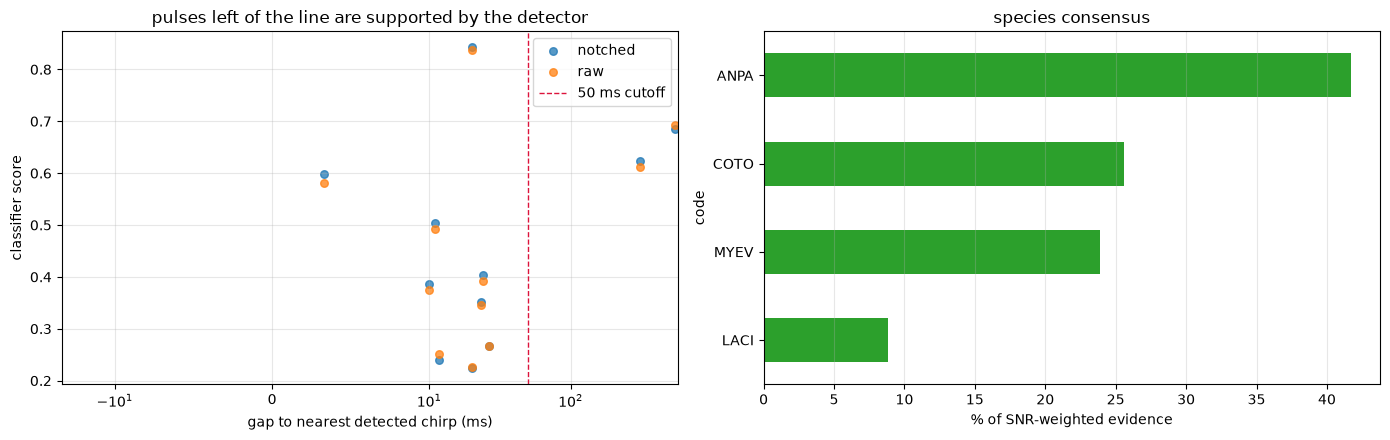

NameError: name 'offset' is not defined

In [ ]:

"""
SageBat species ID - best current attempt with the off-the-shelf NABat ML model.

Combines everything that has been validated so far:

  * energy detection (90th-percentile statistic, which gave 9-21 dB contrast
    where the mean gave 3-9)
  * automatic detection and notching of the tonal insect chorus, run as an
    A/B test since NABat's pulse extractor has only ever seen raw audio
  * time-coincidence filtering against independently detected chirps - this
    removed exactly the two out-of-range NYHU predictions last time, without
    using any species knowledge
  * SNR weighting, because three calls sit at +21 to +30 dB above background
    and six sit at +11 to +12, which is residual-noise level

Prior knowledge, kept out of the scoring and used only at the end for
interpretation: Townsend's big-eared bat (COTO) is known at this cave, and it
is a whispering species, which explains the low SNR.
"""

import os
import re
import subprocess

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, iirnotch, filtfilt

# =========================================================
# Configuration
# =========================================================
FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"
NABAT_DIR = "/home/jgersey/SageBat/nabat-ml"
PYTHON = os.path.expanduser("~/miniconda3/envs/nabat/bin/python")
WORK_DIR = "/home/jgersey/SageBat/bouts_ab"

# detection
N_FFT, HOP = 512, 128
DET_LO, DET_HI = 45_000, 100_000     # detection band (above the chorus)
PCTL, THRESH_DB, MIN_GAP = 90, 5, 3

# chorus notching
SURVEY_S = 3.0
LINE_PROMINENCE_DB = 6
LINE_MAX_WIDTH_HZ = 3000
NOTCH_Q = 35

# bouts
BOUT_GAP_S = 1.0
BOUT_PAD_S = 0.75

# matching
COINCIDENCE_S = 0.05      # pulse must land this close to a detected chirp

TIMEOUT_S = 900

ENV = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
ENV.update(CUDA_VISIBLE_DEVICES="-1", TF_USE_LEGACY_KERAS="1",
           MPLBACKEND="Agg", TF_CPP_MIN_LOG_LEVEL="2")

PULSE_RE = re.compile(
    r"pulse_(\d+)\s+max class\s+(\d+)\((\w+)\),\s+score\s+([0-9.eE+-]+)")

CA = {
    "ANPA": ("pallid bat", 25, 45), "COTO": ("Townsend's big-eared", 20, 45),
    "EPFU": ("big brown", 23, 40), "EUMA": ("spotted bat", 8, 18),
    "EUPE": ("western mastiff", 8, 16), "IDPH": ("Allen's big-eared", 15, 45),
    "LABL": ("western red", 35, 55), "LACI": ("hoary", 16, 30),
    "LANO": ("silver-haired", 24, 40), "LAXA": ("western yellow", 30, 45),
    "MYCA": ("California myotis", 45, 70), "MYCI": ("western small-footed", 38, 60),
    "MYEV": ("long-eared myotis", 35, 60), "MYLU": ("little brown", 38, 60),
    "MYTH": ("fringed myotis", 35, 60), "MYVO": ("long-legged myotis", 38, 60),
    "MYYU": ("Yuma myotis", 45, 70), "NYFE": ("pocketed free-tailed", 18, 30),
    "NYMA": ("big free-tailed", 10, 20), "PAHE": ("canyon bat", 42, 60),
    "TABR": ("Mexican free-tailed", 20, 40),
}

info = sf.info(FULL_WAV)
SR = info.samplerate
WINDOW = np.hanning(N_FFT)
FREQS = np.fft.rfftfreq(N_FFT, d=1 / SR)
DET_BAND = np.where((FREQS >= DET_LO) & (FREQS <= DET_HI))[0]

os.makedirs(WORK_DIR, exist_ok=True)
print(f"{info.duration:.1f} s at {SR} Hz")


def frames(x):
    n = 1 + (len(x) - N_FFT) // HOP
    return np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0] * HOP, x.strides[0]))


def spec_db(x, band=None):
    p = np.abs(np.fft.rfft(frames(x) * WINDOW, axis=1)) ** 2
    if band is not None:
        p = p[:, band]
    return 10 * np.log10(np.maximum(p, 1e-20))


# =========================================================
# 1. Detect chirps, with per-call SNR
# =========================================================
print("\ndetecting ...")
times, snrs = [], []
BLK = int(10.0 * SR)

with sf.SoundFile(FULL_WAV) as f:
    b = 0
    while True:
        x = f.read(frames=BLK, dtype="float64", always_2d=True)
        if len(x) < N_FFT * 4:
            break
        x = np.ascontiguousarray(x[:, 0])
        d = spec_db(x, DET_BAND)
        e = np.percentile(d, PCTL, axis=1)
        base = np.median(e)
        hits = np.where(e > base + THRESH_DB)[0]
        if len(hits):
            for g in np.split(hits, np.where(np.diff(hits) > MIN_GAP)[0] + 1):
                c = int(g[np.argmax(e[g])])
                times.append(b * 10.0 + c * HOP / SR)
                snrs.append(float(e[c] - base))
        b += 1

chirp_times = np.array(times)
chirp_snr = np.array(snrs)
order = np.argsort(chirp_times)
chirp_times, chirp_snr = chirp_times[order], chirp_snr[order]

print(f"{len(chirp_times)} chirps, SNR {chirp_snr.min():.0f}-{chirp_snr.max():.0f} dB "
      f"(median {np.median(chirp_snr):.0f})")
if len(chirp_times) == 0:
    raise SystemExit("no chirps found")


# =========================================================
# 2. Find and notch the tonal chorus
# =========================================================
with sf.SoundFile(FULL_WAV) as f:
    f.seek(int(max(0, chirp_times[0] - SURVEY_S / 2) * SR))
    survey = np.ascontiguousarray(
        f.read(frames=int(SURVEY_S * SR), dtype="float64", always_2d=True)[:, 0])

lta = spec_db(survey).mean(axis=0)
k = max(3, int(2000 / (FREQS[1] - FREQS[0])) | 1)
excess = lta - np.convolve(lta, np.ones(k) / k, mode="same")
peaks, _ = find_peaks(excess, prominence=LINE_PROMINENCE_DB,
                      width=(None, LINE_MAX_WIDTH_HZ / (FREQS[1] - FREQS[0])))
lines = FREQS[peaks]
lines = lines[(lines > 5_000) & (lines < SR / 2 * 0.95)]

print(f"\n{len(lines)} chorus line(s): "
      f"{', '.join(f'{f/1000:.1f}' for f in lines)} kHz")


def denotch(x):
    y = x.astype(np.float64).copy()
    for f0 in lines:
        b_, a_ = iirnotch(f0, NOTCH_Q, fs=SR)
        y = filtfilt(b_, a_, y)
    return y


# =========================================================
# 3. Write bout files, raw and notched
# =========================================================
bout_id = np.concatenate([[0], np.cumsum(np.diff(chirp_times) > BOUT_GAP_S)])
n_bouts = int(bout_id.max()) + 1
print(f"{n_bouts} bout(s)")

bouts = []
for bi in range(n_bouts):
    ts = chirp_times[bout_id == bi]
    t0 = max(0.0, ts.min() - BOUT_PAD_S)
    t1 = min(info.duration, ts.max() + BOUT_PAD_S)
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(int(t0 * SR))
        y = np.ascontiguousarray(
            f.read(frames=int((t1 - t0) * SR), dtype="float64", always_2d=True)[:, 0])

    for variant, sig in [("raw", y), ("notched", denotch(y))]:
        sig = sig / (np.abs(sig).max() + 1e-12) * 0.98
        path = os.path.join(WORK_DIR, f"b{bi:02d}_{variant}.wav")
        sf.write(path, (sig * 32767).astype(np.int16), SR, subtype="PCM_16")
        bouts.append(dict(bout=bi, variant=variant, path=path, t0=t0,
                          n_chirps=len(ts)))
    print(f"  bout {bi}: {t0:.2f}-{t1:.2f}s, {len(ts)} chirps")


# =========================================================
# 4. Classify
# =========================================================
print("\nclassifying (raw vs notched) ...")
rows = []

for bt in bouts:
    out = os.path.join(NABAT_DIR, "classify", f"{bt['variant']}_b{bt['bout']:02d}")
    os.makedirs(out, exist_ok=True)
    try:
        p = subprocess.run(
            [PYTHON, "nabat_ml_cli.py", "-p", out, "-f", bt["path"]],
            cwd=NABAT_DIR, capture_output=True, text=True,
            timeout=TIMEOUT_S, env=ENV)
    except subprocess.TimeoutExpired:
        print(f"  {bt['variant']} bout {bt['bout']}: timeout")
        continue

    hits = PULSE_RE.findall(p.stdout)
    if not hits:
        print(f"  {bt['variant']} bout {bt['bout']}: no pulses  "
              f"({p.stderr.strip().splitlines()[-1][:120] if p.stderr.strip() else 'rc=' + str(p.returncode)})")
        continue

    for ms, cid, code, score in hits:
        t_abs = bt["t0"] + int(ms) / 1000
        gap = float(np.min(np.abs(chirp_times - t_abs)))
        near = int(np.argmin(np.abs(chirp_times - t_abs)))
        rows.append(dict(variant=bt["variant"], bout=bt["bout"], t_abs=t_abs,
                         code=code, score=float(score), gap=gap,
                         matched=gap < COINCIDENCE_S,
                         call_snr=float(chirp_snr[near]) if gap < COINCIDENCE_S else np.nan))
    print(f"  {bt['variant']} bout {bt['bout']}: {len(hits)} pulses")

if not rows:
    raise SystemExit("\nNo pulses classified in either variant.")

df = pd.DataFrame(rows)
df["in_ca"] = df["code"].isin(CA)
df.to_csv("nabat_best_effort.csv", index=False)


# =========================================================
# 5. Compare variants
# =========================================================
print("\n" + "=" * 64)
print(f"{'variant':10s} {'pulses':>7s} {'matched':>8s} {'CA':>5s} {'mean score':>11s}")
for v, g in df.groupby("variant"):
    print(f"{v:10s} {len(g):7d} {int(g.matched.sum()):8d} "
          f"{int(g.in_ca.sum()):5d} {g.score.mean():11.3f}")
print("\nMore matched pulses from the notched variant means removing the chorus")
print("helped NABat's extractor. Fewer means it relied on that energy.")

best = df.groupby("variant")["matched"].sum().idxmax()
print(f"\nusing '{best}' for the identification")
use = df[(df.variant == best) & df.matched & df.in_ca].copy()

if not len(use):
    raise SystemExit("\nNo coincidence-filtered California predictions. "
                     "Report detection only: species indeterminate.")


# =========================================================
# 6. Weighted consensus
# =========================================================
# weight by classifier score AND by how far the call stood above background;
# the +30 dB calls deserve more say than the +11 dB ones
use["weight"] = use["score"] * use["call_snr"]

agg = (use.groupby("code")
          .agg(pulses=("score", "size"), best_score=("score", "max"),
               weight=("weight", "sum"), best_snr=("call_snr", "max"))
          .sort_values("weight", ascending=False))
agg["pct"] = agg["weight"] / agg["weight"].sum() * 100
agg["common"] = [CA[c][0] for c in agg.index]
agg["freq_khz"] = [f"{CA[c][1]}-{CA[c][2]}" for c in agg.index]

print("\n--- SNR-weighted consensus (coincidence-filtered, CA species) ---")
print(agg[["common", "pulses", "best_score", "best_snr", "pct", "freq_khz"]]
      .to_string(float_format=lambda v: f"{v:.2f}"))

top = agg.index[0]
print(f"\ntop: {top} ({CA[top][0]}), {agg.loc[top, 'pct']:.0f}% of weight")

print("\n--- interpretation ---")
print(f"All calls come from {n_bouts} bout(s), so the true answer is one or two")
print("species. Spread across more than that is model uncertainty.")
if "COTO" in agg.index:
    r = agg.loc["COTO"]
    print(f"\nCOTO present: {int(r.pulses)} pulse(s), best score {r.best_score:.2f}, "
          f"{r.pct:.0f}% of weight")
    print("Townsend's is known at this cave and is a whispering species, which")
    print("is consistent with the low SNR. Prior knowledge is legitimate")
    print("evidence in bat acoustics but does not substitute for a vetted ID.")
else:
    print("\nCOTO not predicted on any matched pulse despite known cave occupancy.")
    print("Its calls may simply be below the noise floor here.")


# =========================================================
# 7. Figure
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

for v, g in df.groupby("variant"):
    ax[0].scatter(g.gap * 1000, g.score, s=30, alpha=0.75, label=v)
ax[0].axvline(COINCIDENCE_S * 1000, ls="--", c="crimson", lw=1,
              label=f"{COINCIDENCE_S*1000:.0f} ms cutoff")
ax[0].set_xscale("symlog", linthresh=10)
ax[0].set_xlabel("gap to nearest detected chirp (ms)")
ax[0].set_ylabel("classifier score")
ax[0].set_title("pulses left of the line are supported by the detector")
ax[0].legend(); ax[0].grid(alpha=0.3)

agg["pct"].plot.barh(ax=ax[1], color="tab:green")
ax[1].set_xlabel("% of SNR-weighted evidence")
ax[1].set_title("species consensus")
ax[1].invert_yaxis(); ax[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("nabat_best_effort.png", dpi=140, bbox_inches="tight")
print("\nwrote nabat_best_effort.csv and nabat_best_effort.png")
plt.show()


In [11]:
# getting one species ID from a handful of low-SNR calls is a stretch, but the SNR-weighted

In [13]:
"""
Joint-likelihood species ID for a single bat.

The 14 chirps in bout 0 span 2.2 s at ~6 calls/second - one individual on one
pass. So all classified pulses share ONE ground-truth species, and summing
per-pulse argmax votes is the wrong operation: it reports the model's most
common error rather than pooling evidence.

The right computation is a joint likelihood. If every pulse is the same bat,
multiply the per-pulse probability vectors (sum their logs) and take the
maximum. A species ranked a consistent second at 0.35 across nine pulses beats
one ranked first at 0.30 on five - which plurality voting cannot see.

The CLI only prints the top class, so this script monkeypatches the model's
predict method at runtime to capture the full 31-class softmax, then runs the
CLI in-process. No files in the repo are modified.

RUN WITH THE NABAT ENVIRONMENT'S PYTHON, e.g.

    conda activate nabat
    cd ~/SageBat/nabat-ml
    CUDA_VISIBLE_DEVICES=-1 python ~/joint_species_id.py
"""

import glob
import json
import os
import runpy
import sys

import numpy as np

# =========================================================
# Configuration
# =========================================================
NABAT_DIR = "/home/jgersey/SageBat/nabat-ml"
BOUT_GLOB = "/home/jgersey/SageBat/bouts_ab/*_notched.wav"   # or *_raw.wav
OUT_DIR = os.path.join(NABAT_DIR, "classify_joint")

# Restrict to species recorded at Pinnacles National Park
PINNACLES = {
    "PAHE": "western pipistrelle / canyon bat",
    "LABL": "western red",
    "LACI": "hoary",
    "COTO": "Townsend's big-eared",
    "ANPA": "pallid bat",
    "EPFU": "big brown",
    "MYCA": "California myotis",
    "MYCI": "small-footed myotis",
    "MYEV": "long-eared myotis",
    "MYTH": "fringed myotis",
    "MYVO": "long-legged myotis",
    "MYYU": "Yuma myotis",
    "TABR": "Brazilian free-tailed",
    "EUPE": "western mastiff",
}

# Class indices confirmed from earlier CLI output, used as a fallback and as a
# sanity check on whatever label file we find.
KNOWN_INDICES = {0: "ANPA", 1: "COTO", 7: "LABO", 8: "LACI", 15: "MYEV", 26: "NYHU"}

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
os.environ["MPLBACKEND"] = "Agg"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

os.makedirs(OUT_DIR, exist_ok=True)
sys.path.insert(0, NABAT_DIR)
os.chdir(NABAT_DIR)


# =========================================================
# 1. Find the class labels
# =========================================================
def find_labels():
    """Look for a label list in the repo. Returns list or None."""
    candidates = []
    for pat in ("**/*label*", "**/*class*", "**/*species*"):
        candidates += glob.glob(os.path.join(NABAT_DIR, pat), recursive=True)
    candidates = [c for c in candidates
                  if os.path.isfile(c)
                  and os.path.splitext(c)[1].lower() in (".json", ".txt", ".csv", ".pkl")]

    print("label file candidates:")
    for c in candidates:
        print("  ", os.path.relpath(c, NABAT_DIR))

    for c in candidates:
        ext = os.path.splitext(c)[1].lower()
        try:
            if ext == ".json":
                with open(c) as fh:
                    obj = json.load(fh)
                if isinstance(obj, list) and len(obj) >= 25:
                    return [str(v) for v in obj]
                if isinstance(obj, dict) and len(obj) >= 25:
                    try:
                        return [str(obj[k]) for k in sorted(obj, key=lambda x: int(x))]
                    except (ValueError, KeyError):
                        return [str(v) for v in obj.values()]
            elif ext in (".txt", ".csv"):
                with open(c) as fh:
                    lines = [ln.strip() for ln in fh if ln.strip()]
                if 25 <= len(lines) <= 40:
                    return [ln.split(",")[0] for ln in lines]
        except Exception:
            continue
    return None


LABELS = find_labels()
if LABELS:
    print(f"\nusing {len(LABELS)} labels from repo")
    mismatch = [(i, c, LABELS[i]) for i, c in KNOWN_INDICES.items()
                if i < len(LABELS) and c.upper() not in LABELS[i].upper()]
    if mismatch:
        print("WARNING: label file disagrees with observed class indices:")
        for i, expect, got in mismatch:
            print(f"  index {i}: expected {expect}, file says {got}")
        print("Falling back to observed indices only.")
        LABELS = None
else:
    print("\nno label file found - using the class indices observed from CLI output")


def code_for(i):
    if LABELS and i < len(LABELS):
        token = LABELS[i].strip().upper()
        for c in list(PINNACLES) + list(KNOWN_INDICES.values()):
            if c in token:
                return c
        return token[:12]
    return KNOWN_INDICES.get(i, f"class_{i}")


# =========================================================
# 2. Capture full probability vectors
# =========================================================
import importlib

CAPTURED = []

PredictionCls = None
for modname in ("prediction.prediction", "prediction", "prediction.Prediction"):
    try:
        m = importlib.import_module(modname)
    except Exception:
        continue
    if hasattr(m, "Prediction"):
        PredictionCls = m.Prediction
        print(f"found Prediction in {modname}")
        break

if PredictionCls is None:
    # last resort: walk the package for any class named Prediction
    import pkgutil
    for _, name, _ in pkgutil.walk_packages([NABAT_DIR]):
        try:
            m = importlib.import_module(name)
        except Exception:
            continue
        if hasattr(m, "Prediction"):
            PredictionCls = m.Prediction
            print(f"found Prediction in {name}")
            break

if PredictionCls is None:
    raise SystemExit("could not locate the Prediction class")

_orig_init = PredictionCls.__init__


def _patched_init(self, *args, **kwargs):
    _orig_init(self, *args, **kwargs)
    model = getattr(self, "MODEL", None)
    if model is None:
        print("  (no .MODEL attribute found on Prediction instance)")
        return

    original = model.predict

    def wrapper(*a, **kw):
        out = original(*a, **kw)
        try:
            arr = np.asarray(out)
            if arr.ndim == 2 and arr.shape[1] > 5:
                CAPTURED.append(arr.copy())
        except Exception:
            pass
        return out

    try:
        model.predict = wrapper
    except (AttributeError, TypeError):
        print("  (could not wrap model.predict)")


PredictionCls.__init__ = _patched_init
print("patched Prediction to capture full softmax\n")


# =========================================================
# 3. Run the CLI in-process, once per bout
# =========================================================
wavs = sorted(glob.glob(BOUT_GLOB))
if not wavs:
    raise SystemExit(f"no files matched {BOUT_GLOB}")

print(f"{len(wavs)} file(s) to classify")

per_file = {}
for wav in wavs:
    CAPTURED.clear()
    argv_backup = sys.argv[:]
    sys.argv = ["nabat_ml_cli.py", "-p", OUT_DIR, "-f", wav]
    print(f"\n--- {os.path.basename(wav)} ---")
    try:
        runpy.run_path(os.path.join(NABAT_DIR, "nabat_ml_cli.py"),
                       run_name="__main__")
    except SystemExit:
        pass
    except Exception as exc:
        print(f"  error: {exc}")
    finally:
        sys.argv = argv_backup

    if CAPTURED:
        # The last 2-D capture with the most rows is the per-pulse softmax;
        # earlier ones may come from internal clustering steps.
        best = max(CAPTURED, key=lambda a: a.shape[0])
        per_file[wav] = best
        print(f"  captured {best.shape[0]} pulses x {best.shape[1]} classes")
    else:
        print("  no probability vectors captured")

if not per_file:
    raise SystemExit(
        "\nNothing captured. The model may be invoked by a path this patch does "
        "not cover. Fallback: grep -rn 'max class' . and add a print of the "
        "probability row beside it."
    )


# =========================================================
# 4. Joint likelihood - one bat, one species
# =========================================================
P = np.vstack(list(per_file.values()))
n_pulses, n_classes = P.shape
print(f"\n{n_pulses} pulses, {n_classes} classes")

# rows should already be a softmax; renormalize defensively
P = np.clip(P, 1e-9, None)
P = P / P.sum(axis=1, keepdims=True)

codes = [code_for(i) for i in range(n_classes)]

# Restrict to species recorded at Pinnacles, then renormalize.
mask = np.array([c in PINNACLES for c in codes])
if mask.sum() < 2:
    print("WARNING: could not map classes to Pinnacles species; using all classes")
    mask = np.ones(n_classes, bool)
else:
    print(f"restricting to {int(mask.sum())} Pinnacles species")

Pm = P[:, mask]
Pm = Pm / Pm.sum(axis=1, keepdims=True)
codes_m = [c for c, keep in zip(codes, mask) if keep]

# --- per-pulse argmax, for comparison with the old approach ---
print("\n--- per-pulse top class (the old, wrong aggregation) ---")
votes = {}
for r in range(n_pulses):
    j = int(Pm[r].argmax())
    votes[codes_m[j]] = votes.get(codes_m[j], 0) + 1
    print(f"  pulse {r}: {codes_m[j]:6s} {Pm[r, j]:.3f}")
print("  votes:", dict(sorted(votes.items(), key=lambda kv: -kv[1])))

# --- joint likelihood ---
logp = np.log(Pm).sum(axis=0)          # product of probabilities
logp -= logp.max()
post = np.exp(logp)
post /= post.sum()

print("\n--- joint likelihood across all pulses (one bat, one species) ---")
order = np.argsort(post)[::-1]
for j in order[:8]:
    c = codes_m[j]
    bar = "#" * int(post[j] * 50)
    print(f"  {c:6s} {post[j]*100:6.2f}%  {PINNACLES.get(c,'?'):26s} {bar}")

top = codes_m[order[0]]
runner = codes_m[order[1]]
ratio = post[order[0]] / max(post[order[1]], 1e-12)

print(f"\ntop: {top} ({PINNACLES.get(top,'?')})  at {post[order[0]]*100:.1f}%")
print(f"odds vs {runner}: {ratio:.1f} : 1")

if ratio > 10:
    print("\n-> decisive. The pulses agree once evidence is pooled properly.")
elif ratio > 3:
    print("\n-> suggestive but not conclusive; report with the runner-up noted.")
else:
    print("\n-> the calls do not separate these species. Report at group level:")
    print(f"   {top}/{runner} group, species indeterminate at this SNR.")

# --- geometric-mean view, less dominated by any single confident pulse ---
gm = np.exp(np.log(Pm).mean(axis=0))
gm /= gm.sum()
print("\n--- geometric mean (same ranking, gentler weighting) ---")
for j in np.argsort(gm)[::-1][:5]:
    print(f"  {codes_m[j]:6s} {gm[j]*100:6.2f}%")

np.savez("joint_species_id.npz", probs=P, codes=np.array(codes),
         posterior=post, codes_masked=np.array(codes_m))
print("\nwrote joint_species_id.npz")

label file candidates:

no label file found - using the class indices observed from CLI output
found Prediction in prediction.prediction
patched Prediction to capture full softmax

2 file(s) to classify

--- b00_notched.wav ---
Initializing...
  error: Keras cannot be imported. Check that it is installed.
  no probability vectors captured

--- b01_notched.wav ---
Initializing...
  error: maximum recursion depth exceeded
  no probability vectors captured


SystemExit: 
Nothing captured. The model may be invoked by a path this patch does not cover. Fallback: grep -rn 'max class' . and add a print of the probability row beside it.

/home/jgersey/SageBat/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [14]:
# =========================================================
# Joint-likelihood species ID  (single cell)
# Writes a worker script, runs it in the nabat env, reads results back.
# =========================================================
import os, subprocess, textwrap
import numpy as np

NABAT_DIR  = "/home/jgersey/SageBat/nabat-ml"
PYTHON     = os.path.expanduser("~/miniconda3/envs/nabat/bin/python")
BOUT_GLOB  = "/home/jgersey/SageBat/bouts_ab/*_notched.wav"
WORKER     = "/home/jgersey/SageBat/_joint_worker.py"
NPZ        = "/home/jgersey/SageBat/joint_species_id.npz"

WORKER_SRC = textwrap.dedent(f'''
    import os, sys, glob, runpy, importlib
    import numpy as np

    NABAT_DIR = {NABAT_DIR!r}
    BOUT_GLOB = {BOUT_GLOB!r}
    NPZ       = {NPZ!r}
    OUT_DIR   = os.path.join(NABAT_DIR, "classify_joint")

    os.makedirs(OUT_DIR, exist_ok=True)
    sys.path.insert(0, NABAT_DIR)
    os.chdir(NABAT_DIR)

    CAPTURED = []

    # the class lives in prediction/prediction.py, not the package root
    PredictionCls = None
    for modname in ("prediction.prediction", "prediction"):
        try:
            m = importlib.import_module(modname)
        except Exception as e:
            print("import", modname, "failed:", e)
            continue
        if hasattr(m, "Prediction"):
            PredictionCls = m.Prediction
            print("found Prediction in", modname)
            break
    if PredictionCls is None:
        sys.exit("could not locate Prediction class")

    _orig_init = PredictionCls.__init__

    def _patched_init(self, *a, **kw):
        _orig_init(self, *a, **kw)
        model = getattr(self, "MODEL", None)
        if model is None:
            print("no .MODEL attribute"); return
        original = model.predict
        def wrapper(*aa, **kk):
            out = original(*aa, **kk)
            try:
                arr = np.asarray(out)
                if arr.ndim == 2 and arr.shape[1] > 5:
                    CAPTURED.append(arr.copy())
            except Exception:
                pass
            return out
        model.predict = wrapper

    PredictionCls.__init__ = _patched_init
    print("patched OK")

    wavs = sorted(glob.glob(BOUT_GLOB))
    print(len(wavs), "file(s)")
    blocks = []
    for wav in wavs:
        CAPTURED.clear()
        sys.argv = ["nabat_ml_cli.py", "-p", OUT_DIR, "-f", wav]
        print("---", os.path.basename(wav))
        try:
            runpy.run_path(os.path.join(NABAT_DIR, "nabat_ml_cli.py"),
                           run_name="__main__")
        except SystemExit:
            pass
        except Exception as e:
            print("  error:", e)
        if CAPTURED:
            best = max(CAPTURED, key=lambda a: a.shape[0])
            blocks.append(best)
            print("  captured", best.shape)
        else:
            print("  nothing captured")

    if not blocks:
        sys.exit("NO_VECTORS")

    P = np.vstack(blocks)
    np.savez(NPZ, probs=P)
    print("saved", P.shape, "to", NPZ)
''')

with open(WORKER, "w") as f:
    f.write(WORKER_SRC)

env = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
env.update(CUDA_VISIBLE_DEVICES="-1", TF_USE_LEGACY_KERAS="1",
           MPLBACKEND="Agg", TF_CPP_MIN_LOG_LEVEL="2")

p = subprocess.run([PYTHON, WORKER], capture_output=True, text=True,
                   cwd=NABAT_DIR, env=env, timeout=1800)
print(p.stdout[-4000:])
if p.returncode != 0:
    print("STDERR:\n", p.stderr[-3000:])

found Prediction in prediction.prediction
patched OK
2 file(s)
--- b00_notched.wav
Initializing...
Processing a single wav file
Processing: /home/jgersey/SageBat/bouts_ab/b00_notched.wav in path /home/jgersey/SageBat/nabat-ml/classify_joint

1/1 [==============================] - 0s 125ms/step
pulse_770 max class 15(MYEV), score 0.8424823880195618
pulse_830 max class 0(ANPA), score 0.5032724142074585
pulse_890 max class 1(COTO), score 0.5984576344490051
pulse_920 max class 0(ANPA), score 0.26756855845451355
pulse_1250 max class 0(ANPA), score 0.22435764968395233
pulse_1280 max class 0(ANPA), score 0.38658562302589417
pulse_1310 max class 8(LACI), score 0.2389446496963501
pulse_1400 max class 15(MYEV), score 0.40436500310897827
pulse_1460 max class 0(ANPA), score 0.35082221031188965
pulse_2030 max class 26(NYHU), score 0.6846643686294556
  captured (10, 31)
--- b01_notched.wav
Initializing...
Processing a single wav file
Processing: /home/jgersey/SageBat/bouts_ab/b01_notched.wav in path

In [15]:
KNOWN = {0: "ANPA", 1: "COTO", 7: "LABO", 8: "LACI", 15: "MYEV", 26: "NYHU"}
PINNACLES = {"PAHE","LABL","LACI","COTO","ANPA","EPFU","MYCA","MYCI",
             "MYEV","MYTH","MYVO","MYYU","TABR","EUPE"}

P = np.load(NPZ)["probs"]
P = np.clip(P, 1e-9, None); P = P / P.sum(axis=1, keepdims=True)
print(f"{P.shape[0]} pulses x {P.shape[1]} classes")

codes = [KNOWN.get(i, f"class_{i}") for i in range(P.shape[1])]
mask  = np.array([c in PINNACLES for c in codes])
if mask.sum() < 2:
    mask = np.ones(P.shape[1], bool)
Pm = P[:, mask]; Pm = Pm / Pm.sum(axis=1, keepdims=True)
cm = [c for c, k in zip(codes, mask) if k]

print("\nper-pulse argmax (old aggregation):")
for r in range(Pm.shape[0]):
    j = int(Pm[r].argmax())
    print(f"  pulse {r}: {cm[j]:8s} {Pm[r, j]:.3f}")

logp = np.log(Pm).sum(axis=0); logp -= logp.max()
post = np.exp(logp); post /= post.sum()

print("\njoint likelihood (one bat, one species):")
for j in np.argsort(post)[::-1][:6]:
    print(f"  {cm[j]:8s} {post[j]*100:6.2f}%  {'#'*int(post[j]*40)}")

o = np.argsort(post)[::-1]
print(f"\nodds {cm[o[0]]} vs {cm[o[1]]}: {post[o[0]]/max(post[o[1]],1e-12):.1f} : 1")

11 pulses x 31 classes

per-pulse argmax (old aggregation):
  pulse 0: MYEV     0.974
  pulse 1: ANPA     0.652
  pulse 2: COTO     0.771
  pulse 3: ANPA     0.467
  pulse 4: ANPA     0.391
  pulse 5: ANPA     0.613
  pulse 6: LACI     0.427
  pulse 7: MYEV     0.808
  pulse 8: ANPA     0.578
  pulse 9: LACI     0.907
  pulse 10: LACI     0.958

joint likelihood (one bat, one species):
  ANPA      99.53%  #######################################
  MYEV       0.40%  
  COTO       0.07%  
  LACI       0.00%  

odds ANPA vs MYEV: 248.7 : 1


In [16]:
import glob, os, re, json

NABAT_DIR = "/home/jgersey/SageBat/nabat-ml"

hits = []
for path in glob.glob(os.path.join(NABAT_DIR, "**", "*"), recursive=True):
    if not os.path.isfile(path):
        continue
    if os.path.splitext(path)[1].lower() not in (".py", ".json", ".txt", ".csv", ".yaml", ".yml"):
        continue
    try:
        txt = open(path, errors="ignore").read()
    except Exception:
        continue
    if "ANPA" in txt and "COTO" in txt:
        hits.append(path)

print("files containing species codes:")
for h in hits:
    print("  ", os.path.relpath(h, NABAT_DIR))

CODE_RE = re.compile(r"\b([A-Z]{4})\b")
LABELS = None
for h in hits:
    txt = open(h, errors="ignore").read()
    for m in re.finditer(r"[\[\{]([^\[\]\{\}]{200,})[\]\}]", txt, re.S):
        codes = CODE_RE.findall(m.group(1))
        seen, uniq = set(), []
        for c in codes:
            if c not in seen:
                seen.add(c); uniq.append(c)
        if 28 <= len(uniq) <= 33:
            LABELS = uniq
            print(f"\ncandidate list ({len(uniq)}) from {os.path.relpath(h, NABAT_DIR)}:")
            print(uniq)
            break
    if LABELS:
        break

if LABELS:
    check = {0: "ANPA", 1: "COTO", 8: "LACI", 15: "MYEV", 26: "NYHU"}
    ok = all(i < len(LABELS) and LABELS[i] == c for i, c in check.items())
    print("\nmatches observed indices:", ok)
    if not ok:
        for i, c in check.items():
            got = LABELS[i] if i < len(LABELS) else "-"
            print(f"  index {i}: expected {c}, got {got}")
else:
    print("\nno list auto-extracted — paste the output above and I'll parse it")

files containing species codes:
   db.py

no list auto-extracted — paste the output above and I'll parse it


In [17]:
import os, subprocess, textwrap
import numpy as np

NABAT_DIR = "/home/jgersey/SageBat/nabat-ml"
PYTHON    = os.path.expanduser("~/miniconda3/envs/nabat/bin/python")
BOUT_GLOB = "/home/jgersey/SageBat/bouts_ab/*_notched.wav"
WORKER    = "/home/jgersey/SageBat/_joint_worker.py"
NPZ       = "/home/jgersey/SageBat/joint_per_bout.npz"

WORKER_SRC = textwrap.dedent(f'''
    import os, sys, glob, runpy, importlib
    import numpy as np

    NABAT_DIR = {NABAT_DIR!r}
    BOUT_GLOB = {BOUT_GLOB!r}
    NPZ       = {NPZ!r}
    OUT_DIR   = os.path.join(NABAT_DIR, "classify_joint")

    os.makedirs(OUT_DIR, exist_ok=True)
    sys.path.insert(0, NABAT_DIR)
    os.chdir(NABAT_DIR)

    CAPTURED = []
    PredictionCls = None
    for modname in ("prediction.prediction", "prediction"):
        try:
            m = importlib.import_module(modname)
        except Exception:
            continue
        if hasattr(m, "Prediction"):
            PredictionCls = m.Prediction; break
    if PredictionCls is None:
        sys.exit("could not locate Prediction class")

    _orig = PredictionCls.__init__
    def _patched(self, *a, **kw):
        _orig(self, *a, **kw)
        model = getattr(self, "MODEL", None)
        if model is None: return
        orig_predict = model.predict
        def wrapper(*aa, **kk):
            out = orig_predict(*aa, **kk)
            try:
                arr = np.asarray(out)
                if arr.ndim == 2 and arr.shape[1] > 5:
                    CAPTURED.append(arr.copy())
            except Exception:
                pass
            return out
        model.predict = wrapper
    PredictionCls.__init__ = _patched

    out = {{}}
    for wav in sorted(glob.glob(BOUT_GLOB)):
        CAPTURED.clear()
        sys.argv = ["nabat_ml_cli.py", "-p", OUT_DIR, "-f", wav]
        key = os.path.splitext(os.path.basename(wav))[0]
        print("---", key)
        try:
            runpy.run_path(os.path.join(NABAT_DIR, "nabat_ml_cli.py"), run_name="__main__")
        except SystemExit:
            pass
        except Exception as e:
            print("  error:", e)
        if CAPTURED:
            best = max(CAPTURED, key=lambda a: a.shape[0])
            out[key] = best
            print("  captured", best.shape)

    if not out:
        sys.exit("NO_VECTORS")
    np.savez(NPZ, **out)
    print("saved", list(out), "->", NPZ)
''')

open(WORKER, "w").write(WORKER_SRC)

env = {k: v for k, v in os.environ.items() if k != "MPLBACKEND"}
env.update(CUDA_VISIBLE_DEVICES="-1", TF_USE_LEGACY_KERAS="1",
           MPLBACKEND="Agg", TF_CPP_MIN_LOG_LEVEL="2")

p = subprocess.run([PYTHON, WORKER], capture_output=True, text=True,
                   cwd=NABAT_DIR, env=env, timeout=1800)
print(p.stdout[-3000:])
if p.returncode != 0:
    print("STDERR:\n", p.stderr[-2000:])

--- b00_notched
Initializing...
Processing a single wav file
Processing: /home/jgersey/SageBat/bouts_ab/b00_notched.wav in path /home/jgersey/SageBat/nabat-ml/classify_joint

1/1 [==============================] - 0s 115ms/step
pulse_770 max class 15(MYEV), score 0.8424823880195618
pulse_830 max class 0(ANPA), score 0.5032724142074585
pulse_890 max class 1(COTO), score 0.5984576344490051
pulse_920 max class 0(ANPA), score 0.26756855845451355
pulse_1250 max class 0(ANPA), score 0.22435764968395233
pulse_1280 max class 0(ANPA), score 0.38658562302589417
pulse_1310 max class 8(LACI), score 0.2389446496963501
pulse_1400 max class 15(MYEV), score 0.40436500310897827
pulse_1460 max class 0(ANPA), score 0.35082221031188965
pulse_2030 max class 26(NYHU), score 0.6846643686294556
  captured (10, 31)
--- b01_notched
Initializing...
Processing a single wav file
Processing: /home/jgersey/SageBat/bouts_ab/b01_notched.wav in path /home/jgersey/SageBat/nabat-ml/classify_joint

1/1 [==================

In [18]:
import numpy as np

PINNACLES = {"PAHE","LABL","LACI","COTO","ANPA","EPFU","MYCA","MYCI",
             "MYEV","MYTH","MYVO","MYYU","TABR","EUPE"}
FALLBACK  = {0:"ANPA", 1:"COTO", 7:"LABO", 8:"LACI", 15:"MYEV", 26:"NYHU"}

z = np.load(NPZ)
keys = sorted(z.files)
n_classes = z[keys[0]].shape[1]

codes = (LABELS if (LABELS and len(LABELS) == n_classes)
         else [FALLBACK.get(i, f"class_{i}") for i in range(n_classes)])
mask = np.array([c in PINNACLES for c in codes])
cm = [c for c, k in zip(codes, mask) if k]
print(f"{n_classes} classes, {mask.sum()} on the Pinnacles list: {cm}")
if mask.sum() < 8:
    print("WARNING: fewer than 8 Pinnacles species mapped — Cell 1 didn't find "
          "the full label list, so this comparison is incomplete")

def analyse(P, title):
    P = np.clip(P, 1e-9, None); P = P / P.sum(axis=1, keepdims=True)
    Pm = P[:, mask]; Pm = Pm / Pm.sum(axis=1, keepdims=True)
    print(f"\n=== {title} — {Pm.shape[0]} pulse(s) ===")
    for r in range(Pm.shape[0]):
        j = int(Pm[r].argmax())
        top3 = np.argsort(Pm[r])[::-1][:3]
        print("   " + "  ".join(f"{cm[k]}:{Pm[r,k]:.2f}" for k in top3))
    lp = np.log(Pm).sum(axis=0); lp -= lp.max()
    post = np.exp(lp); post /= post.sum()
    o = np.argsort(post)[::-1]
    print("  joint:")
    for j in o[:4]:
        print(f"    {cm[j]:6s} {post[j]*100:6.2f}%")
    print(f"  odds {cm[o[0]]} vs {cm[o[1]]}: {post[o[0]]/max(post[o[1]],1e-12):.1f}:1")
    return post, o

for k in keys:
    analyse(z[k], k)

print("\n" + "="*50)
print("Pooling across bouts is only valid if both are the same individual.")
print("Bouts 190 s apart are probably different bats — compare, don't merge.")

31 classes, 4 on the Pinnacles list: ['ANPA', 'COTO', 'LACI', 'MYEV']

=== b00_notched — 10 pulse(s) ===
   MYEV:0.97  ANPA:0.02  LACI:0.01
   ANPA:0.65  COTO:0.22  MYEV:0.11
   COTO:0.77  ANPA:0.19  MYEV:0.03
   ANPA:0.47  COTO:0.41  MYEV:0.08
   ANPA:0.39  MYEV:0.34  COTO:0.21
   ANPA:0.61  COTO:0.30  MYEV:0.04
   LACI:0.43  ANPA:0.33  COTO:0.24
   MYEV:0.81  ANPA:0.12  COTO:0.06
   ANPA:0.58  COTO:0.23  MYEV:0.17
   LACI:0.91  MYEV:0.08  ANPA:0.01
  joint:
    ANPA    99.18%
    COTO     0.53%
    MYEV     0.29%
    LACI     0.00%
  odds ANPA vs COTO: 188.9:1

=== b01_notched — 1 pulse(s) ===
   LACI:0.96  MYEV:0.02  ANPA:0.02
  joint:
    LACI    95.82%
    MYEV     2.29%
    ANPA     1.67%
    COTO     0.23%
  odds LACI vs MYEV: 41.9:1

Pooling across bouts is only valid if both are the same individual.
Bouts 190 s apart are probably different bats — compare, don't merge.


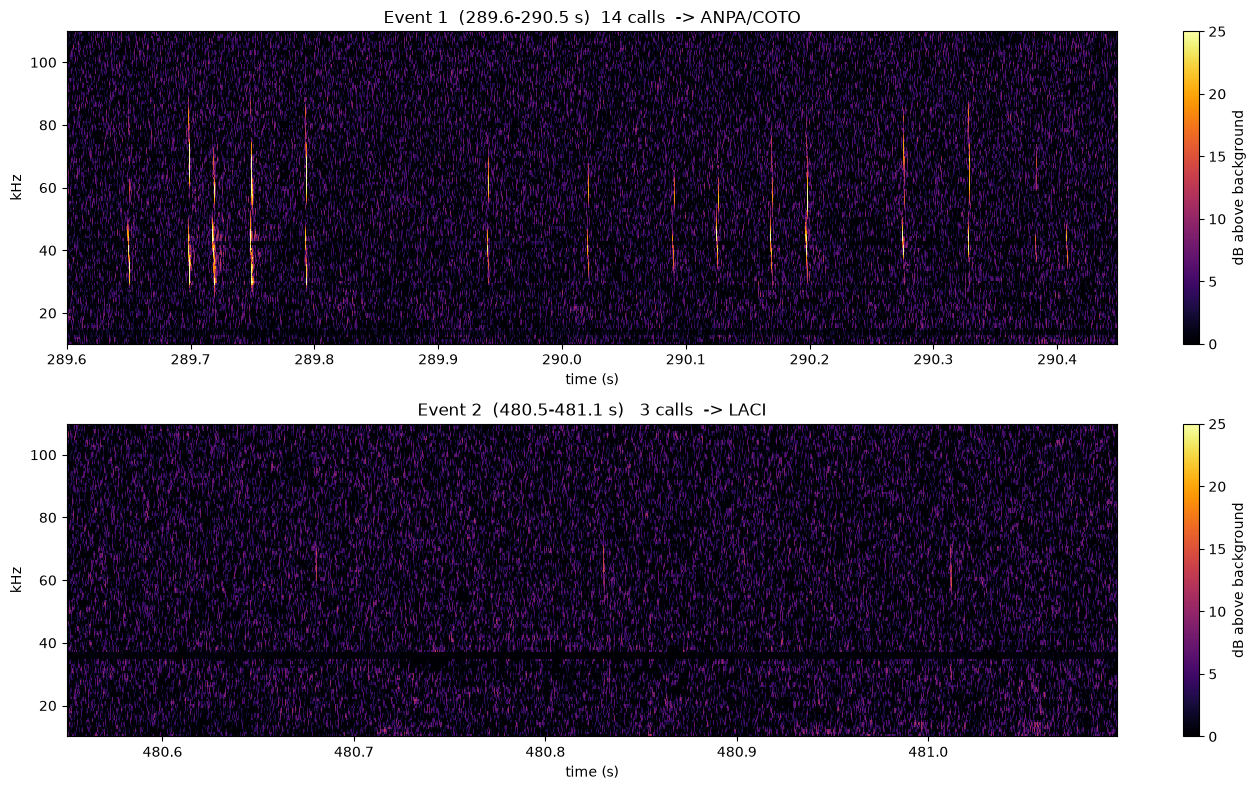

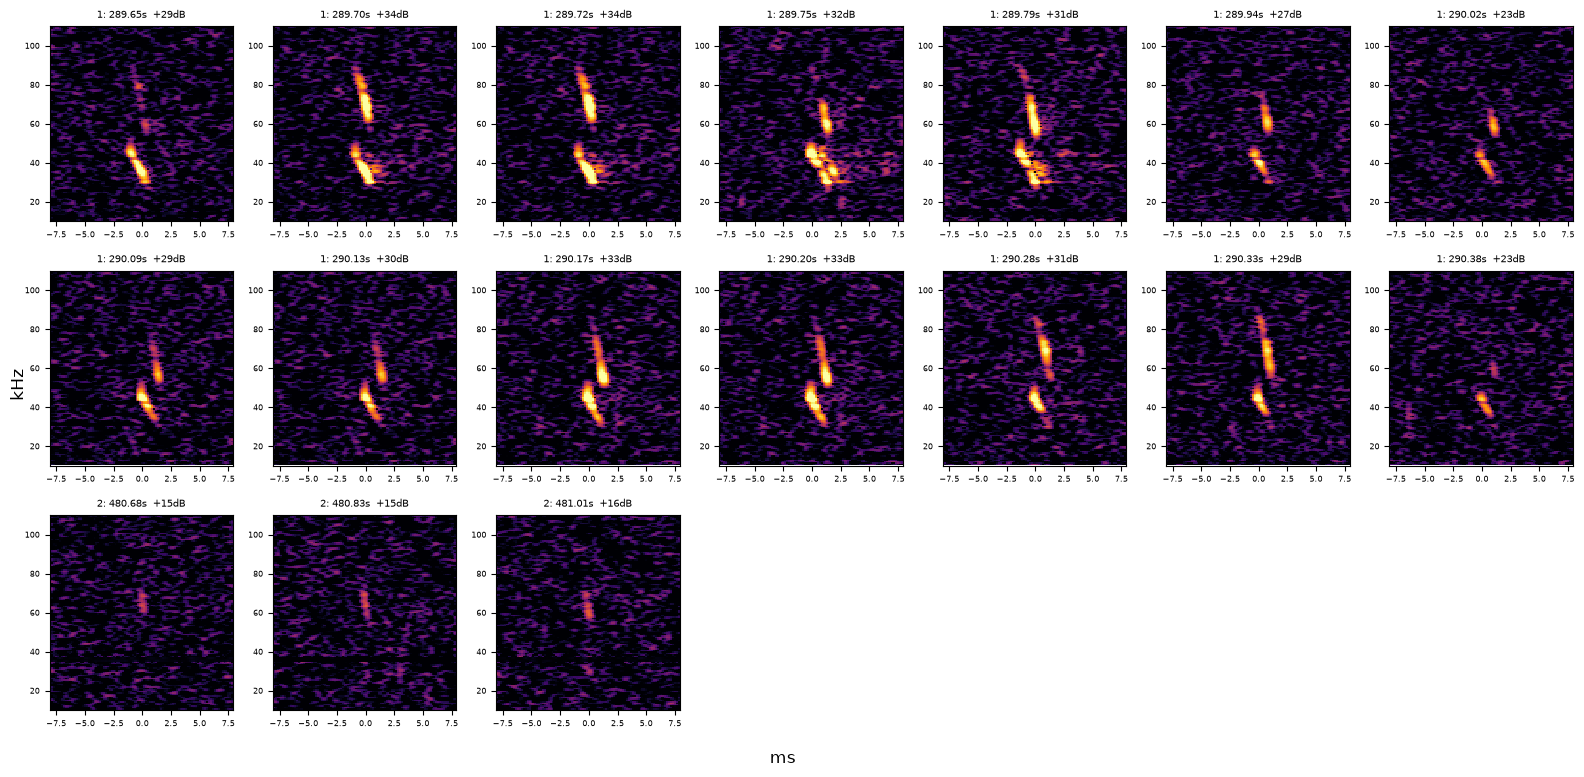

In [19]:
import numpy as np, soundfile as sf, matplotlib.pyplot as plt

FULL_WAV = "/home/jgersey/SageBat/20260414_100939.wav"
N_FFT, HOP = 512, 64          # finer hop than detection, for shape
F_LO, F_HI = 10_000, 110_000

EVENTS = {
    "Event 1  (289.6-290.5 s)  14 calls  -> ANPA/COTO": (289.60, 290.45),
    "Event 2  (480.5-481.1 s)   3 calls  -> LACI":       (480.55, 481.10),
}
CALLS = {
    "Event 1": [289.65, 289.70, 289.72, 289.75, 289.79, 289.94, 290.02,
                290.09, 290.13, 290.17, 290.20, 290.28, 290.33, 290.38],
    "Event 2": [480.68, 480.83, 481.01],
}

info = sf.info(FULL_WAV); SR = info.samplerate
win = np.hanning(N_FFT)
freqs = np.fft.rfftfreq(N_FFT, 1/SR)
keep = np.where((freqs >= F_LO) & (freqs <= F_HI))[0]
fk = freqs[keep] / 1000

def grab(t0, t1):
    with sf.SoundFile(FULL_WAV) as f:
        f.seek(int(t0 * SR))
        return np.ascontiguousarray(
            f.read(frames=int((t1-t0)*SR), dtype="float64", always_2d=True)[:, 0])

def spec(x, subtract=True):
    n = 1 + (len(x) - N_FFT) // HOP
    fr = np.lib.stride_tricks.as_strided(
        x, shape=(n, N_FFT), strides=(x.strides[0]*HOP, x.strides[0]))
    p = (np.abs(np.fft.rfft(fr * win, axis=1)) ** 2)[:, keep]
    d = 10*np.log10(np.maximum(p, 1e-20))
    return d - np.median(d, axis=0, keepdims=True) if subtract else d

# ---------- figure 1: the two events ----------
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, (title, (t0, t1)) in zip(axes, EVENTS.items()):
    d = spec(grab(t0, t1))
    tt = t0 + np.arange(d.shape[0]) * HOP / SR
    im = ax.pcolormesh(tt, fk, d.T, shading="auto", cmap="inferno", vmin=0, vmax=25)
    ax.set_title(title); ax.set_ylabel("kHz"); ax.set_xlabel("time (s)")
    plt.colorbar(im, ax=ax, label="dB above background")
plt.tight_layout(); plt.show()

# ---------- figure 2: individual calls, matched axes ----------
VIEW_MS = 16
half = int(VIEW_MS/1000 * SR / HOP / 2)
ncols = 7
rows = [("Event 1", CALLS["Event 1"]), ("Event 2", CALLS["Event 2"])]
nrows = sum(int(np.ceil(len(v)/ncols)) for _, v in rows)

fig, axes = plt.subplots(nrows, ncols, figsize=(2.3*ncols, 2.6*nrows), squeeze=False)
r = 0
for label, times in rows:
    for i, t in enumerate(times):
        if i and i % ncols == 0:
            r += 1
        ax = axes[r][i % ncols]
        d = spec(grab(t - 0.15, t + 0.15))
        c = d.shape[0] // 2
        # recentre on the strongest frame above 25 kHz
        band = np.where(fk >= 25)[0]
        w = int(0.04 * SR / HOP)
        loc = max(0, c-w) + int(d[max(0, c-w):c+w][:, band].max(axis=1).argmax())
        seg = d[max(0, loc-half):loc+half]
        tm = (np.arange(seg.shape[0]) - seg.shape[0]/2) * HOP / SR * 1000
        ax.pcolormesh(tm, fk, seg.T, shading="auto", cmap="inferno", vmin=0, vmax=25)
        ax.set_title(f"{label[-1]}: {t:.2f}s  +{seg.max():.0f}dB", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_ylim(10, 110)
    for j in range(len(times) % ncols or ncols, ncols):
        axes[r][j].axis("off")
    r += 1

fig.supxlabel("ms"); fig.supylabel("kHz")
plt.tight_layout(); plt.show()